### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd 


In [3]:
font = {'size'   : 20}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 
matplotlib.rcParams['figure.dpi'] = 300

In [4]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image  
import pydotplus

#from sklearn.tree import export_graphviz 

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [5]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [6]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

In [7]:
print(f"Tamaño del dataset: {LearningSet.shape[0]} filas, {LearningSet.shape[1]} columnas")

Tamaño del dataset: 18 filas, 5 columnas


In [8]:
print("Categorías de P_HABITABLE")
display(LearningSet['P_HABITABLE'].value_counts())

Categorías de P_HABITABLE


P_HABITABLE
0    10
1     8
Name: count, dtype: int64

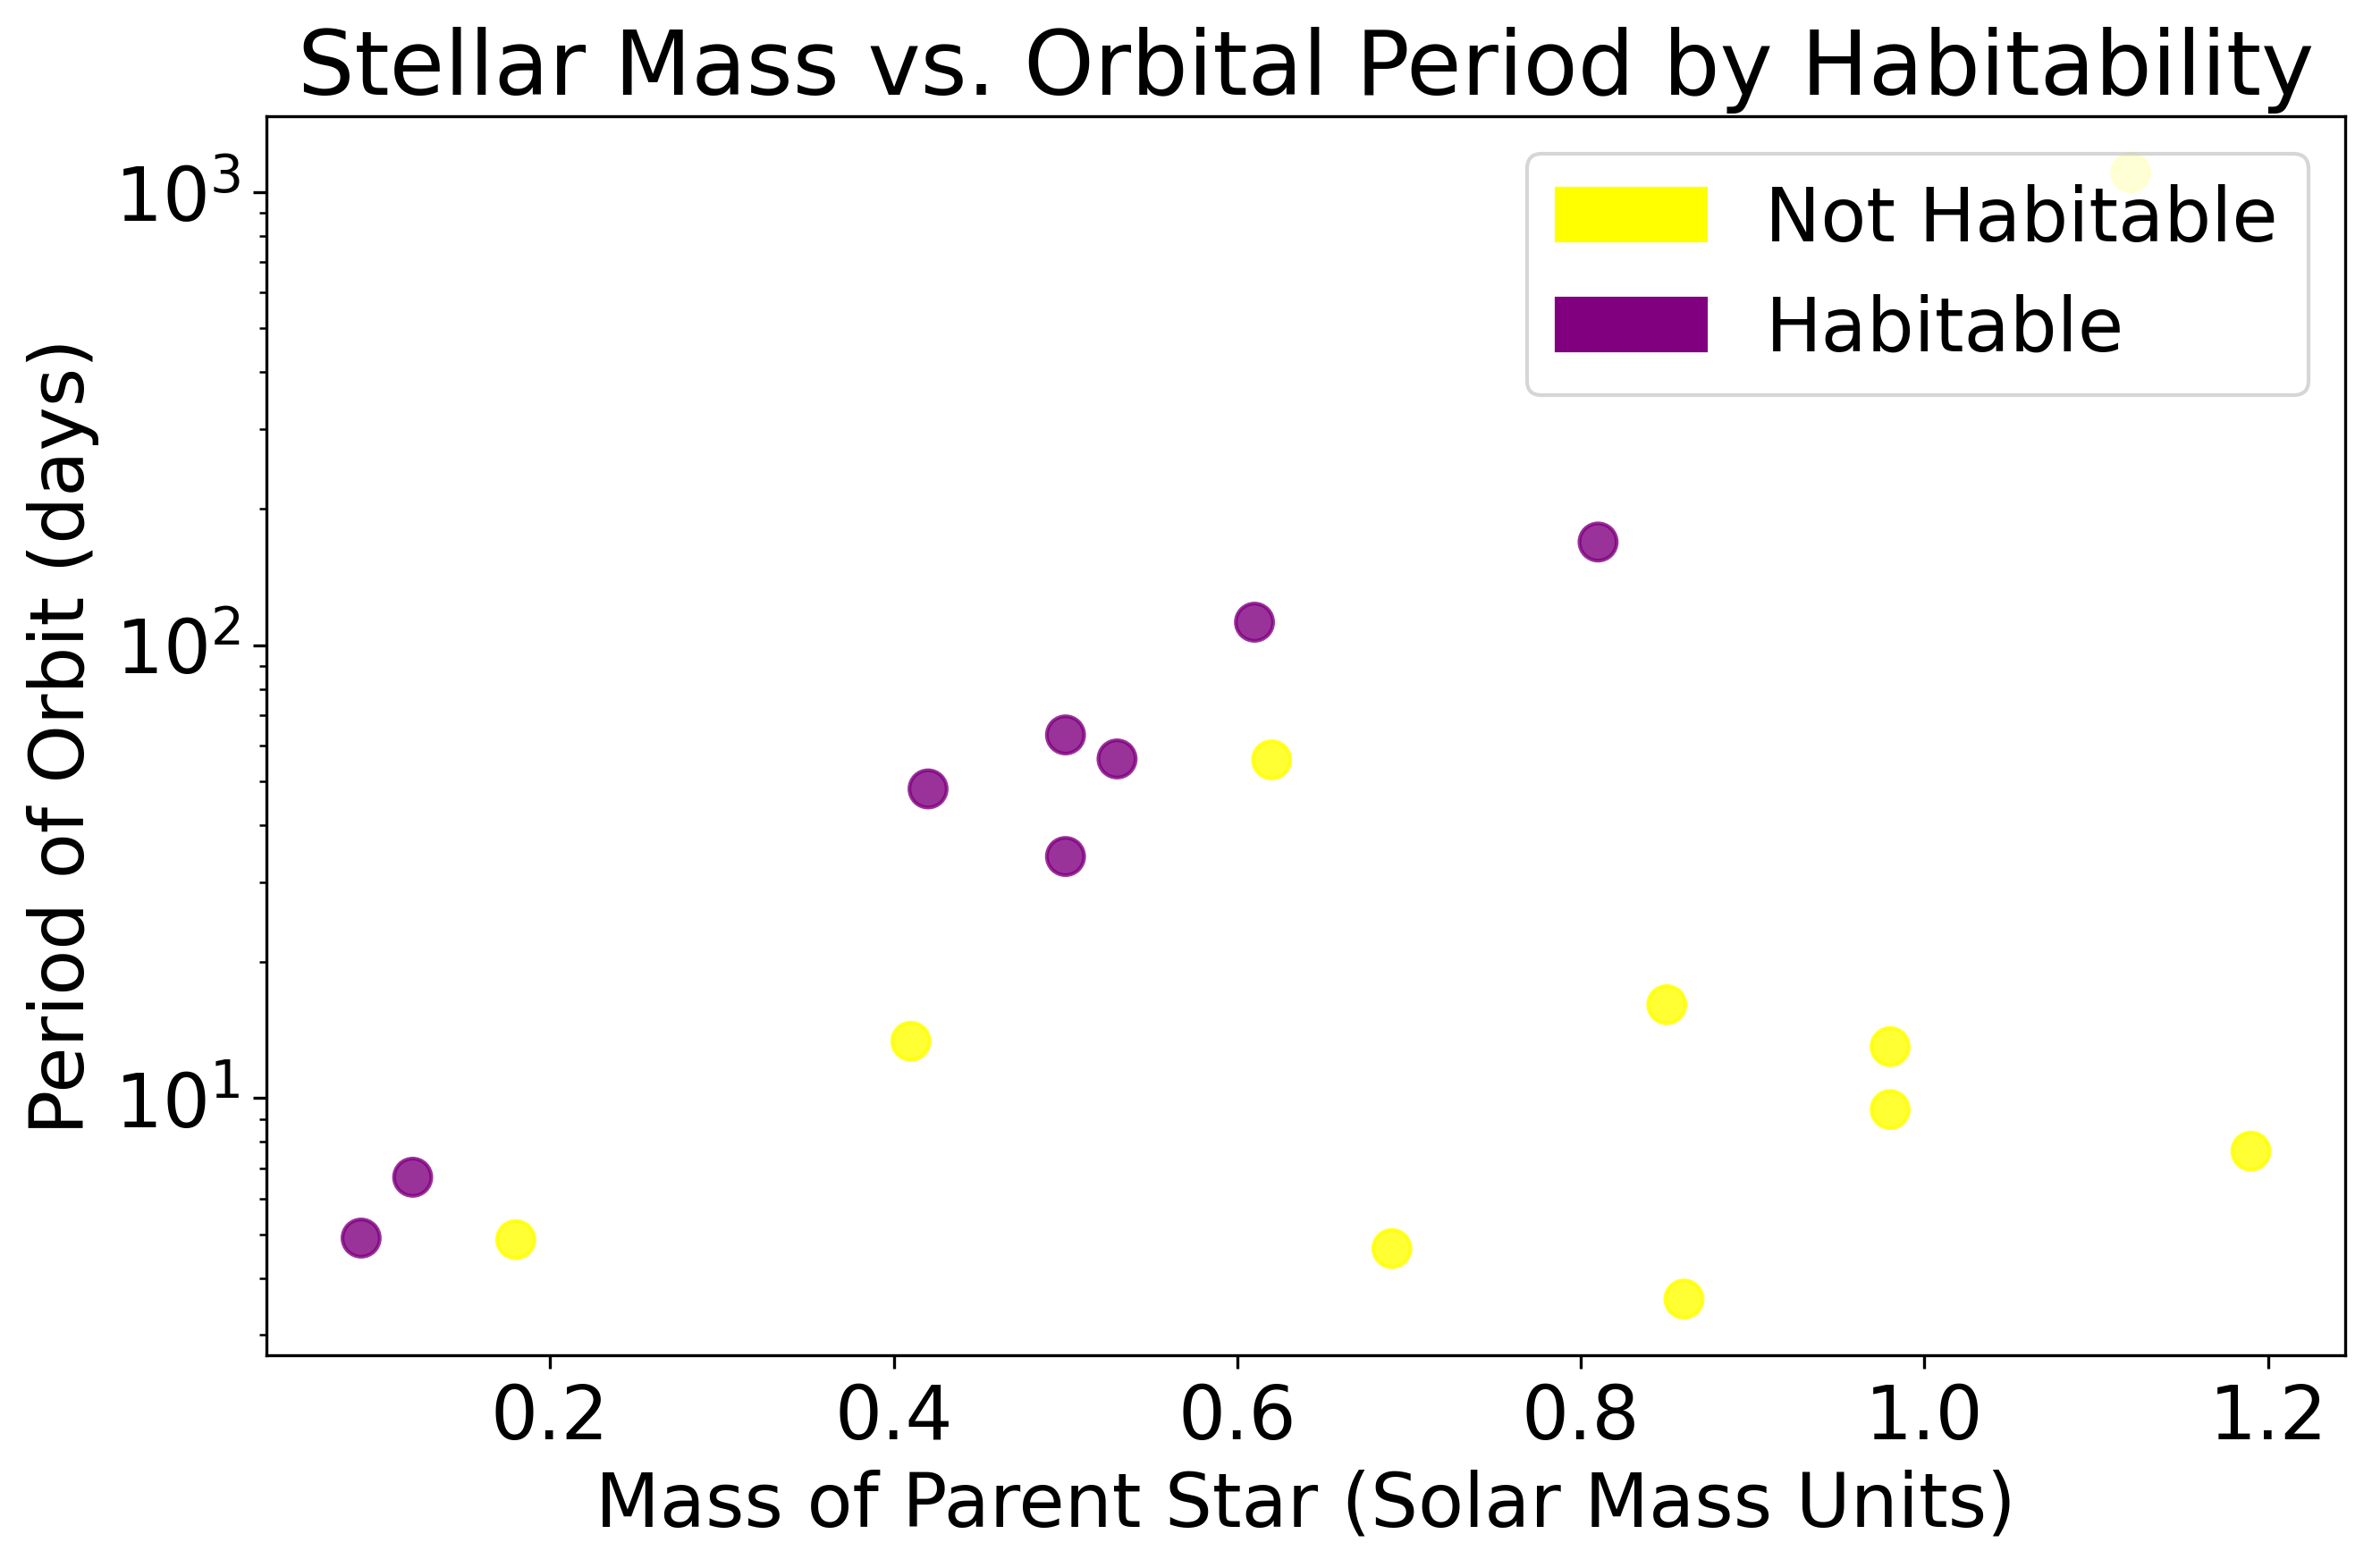

In [9]:
plt.figure(figsize=(10, 6))


cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#FFFF00', '#800080'])

plt.scatter(LearningSet['S_MASS'], LearningSet['P_PERIOD'],
            c=LearningSet['P_HABITABLE'], cmap=cmap, s=100, alpha=0.8)
plt.yscale('log')
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)')
plt.title('Stellar Mass vs. Orbital Period by Habitability')


yellowpatch = mpatches.Patch(color='#FFFF00', label='Not Habitable')
purplepatch = mpatches.Patch(color='#800080', label='Habitable')
plt.legend(handles=[yellowpatch, purplepatch], loc='upper right')


plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**


Aunque hay una tendencia de que los planetas habitables (morados) se encuentran en una región particular, existen puntos de ambas clases mezclados en varias áreas. Esto sugiere que un clasificador lineal simple probablemente no sería suficiente para separarlos perfectamente. Un modelo más complejo, como un árbol de decisión o kNN, que puede definir límites de decisión no lineales, podría funcionar mejor, pero la superposición indica que la separación no es trivial.

### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [10]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [11]:
TrainSet =  LearningSet.iloc[:13,:]  

TestSet = LearningSet.iloc[13:,:]

In [12]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [13]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [14]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento

Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [15]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [16]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba

ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [17]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [18]:
ytrain

0     0
1     0
2     0
3     1
4     0
5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
Name: P_HABITABLE, dtype: int64

### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [19]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión


In [20]:
model = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros

model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/) 

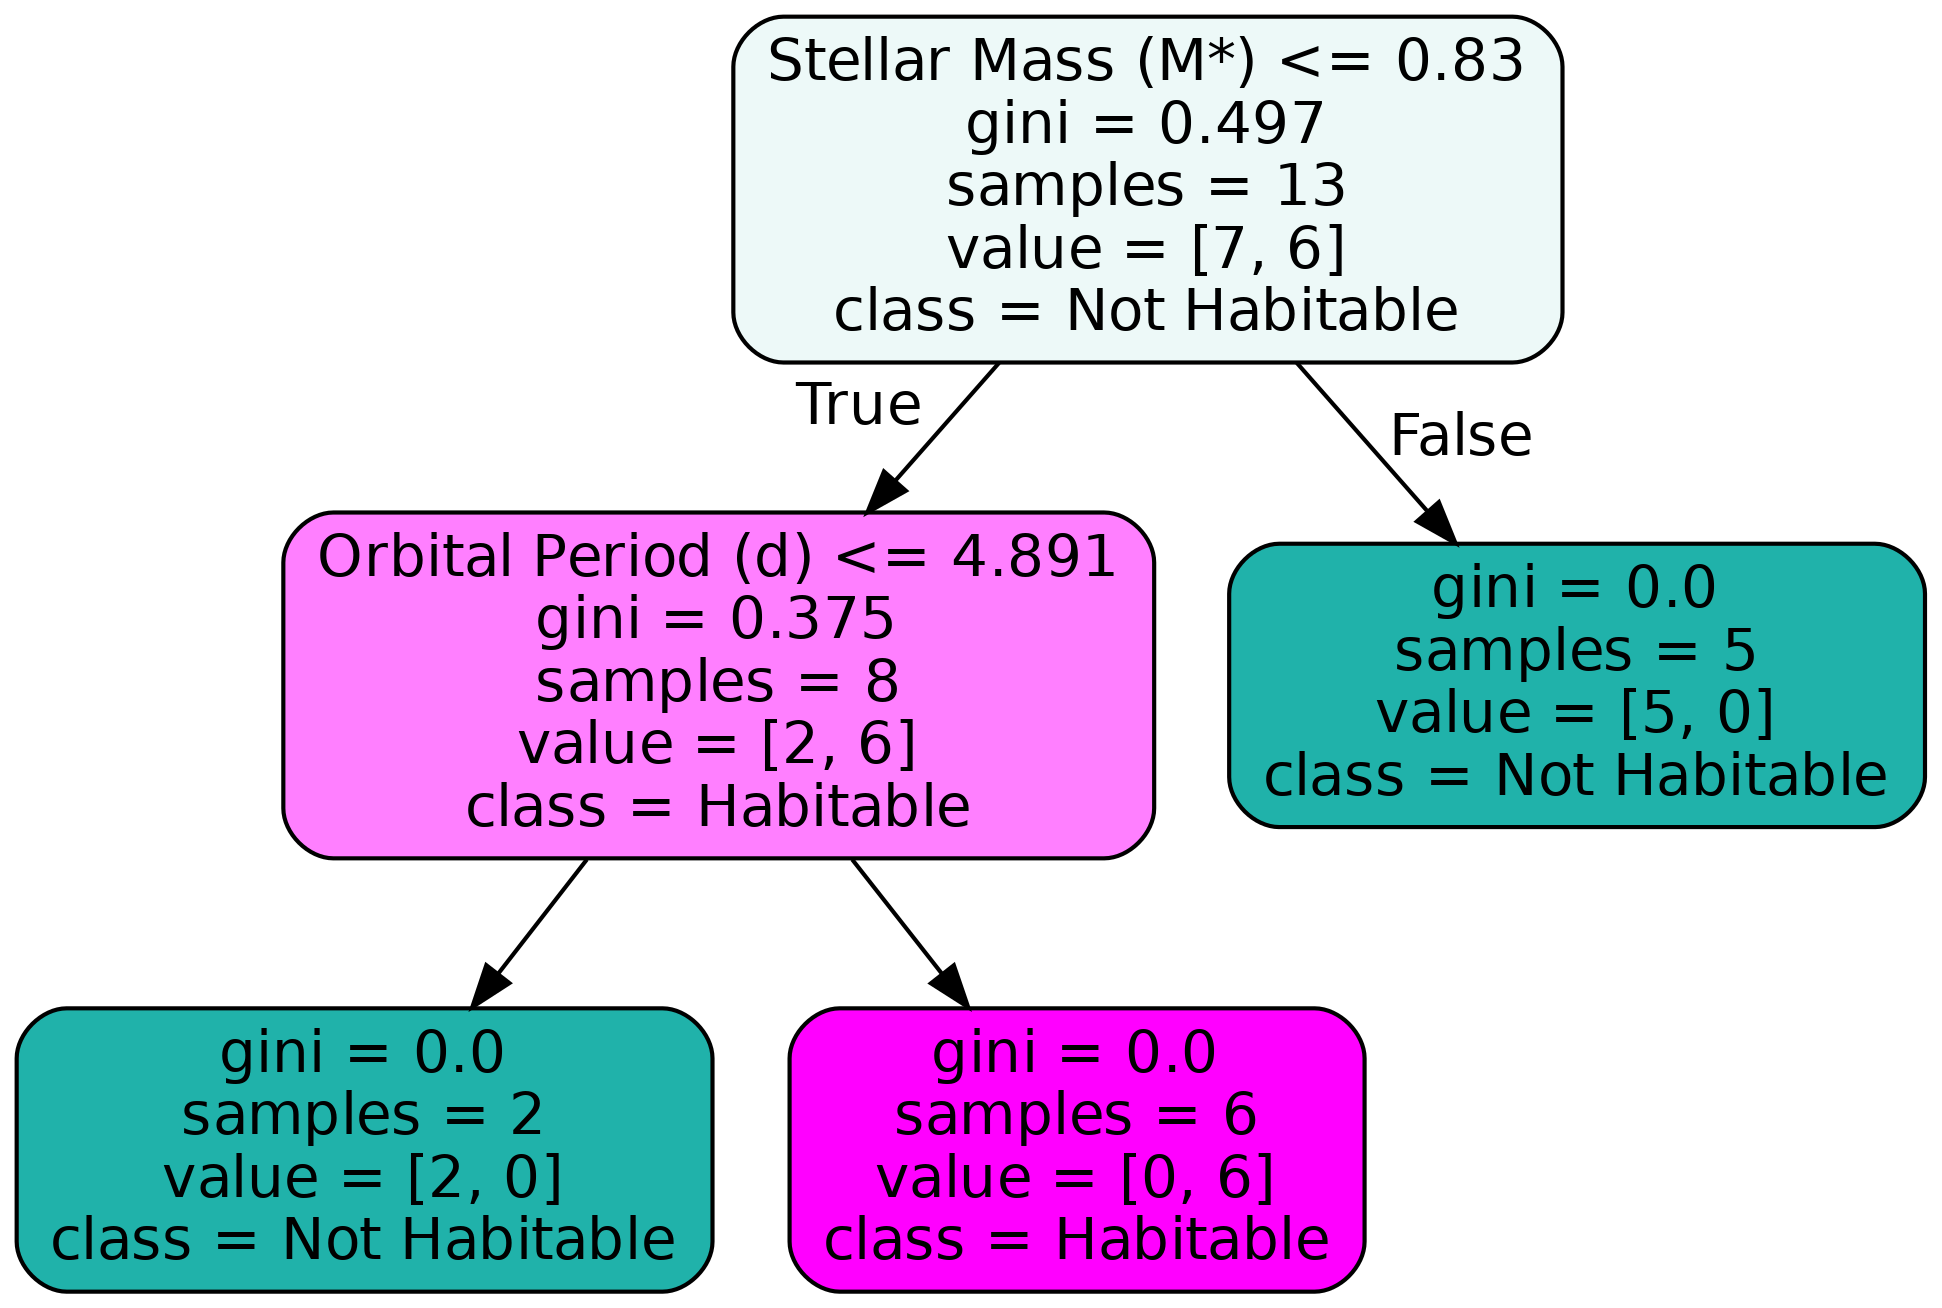

In [21]:
from sklearn.tree import export_graphviz
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))  
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]
        
        values = [int(255 * v / sum(values)) for v in values]
            
        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

### Visualización de sklearn

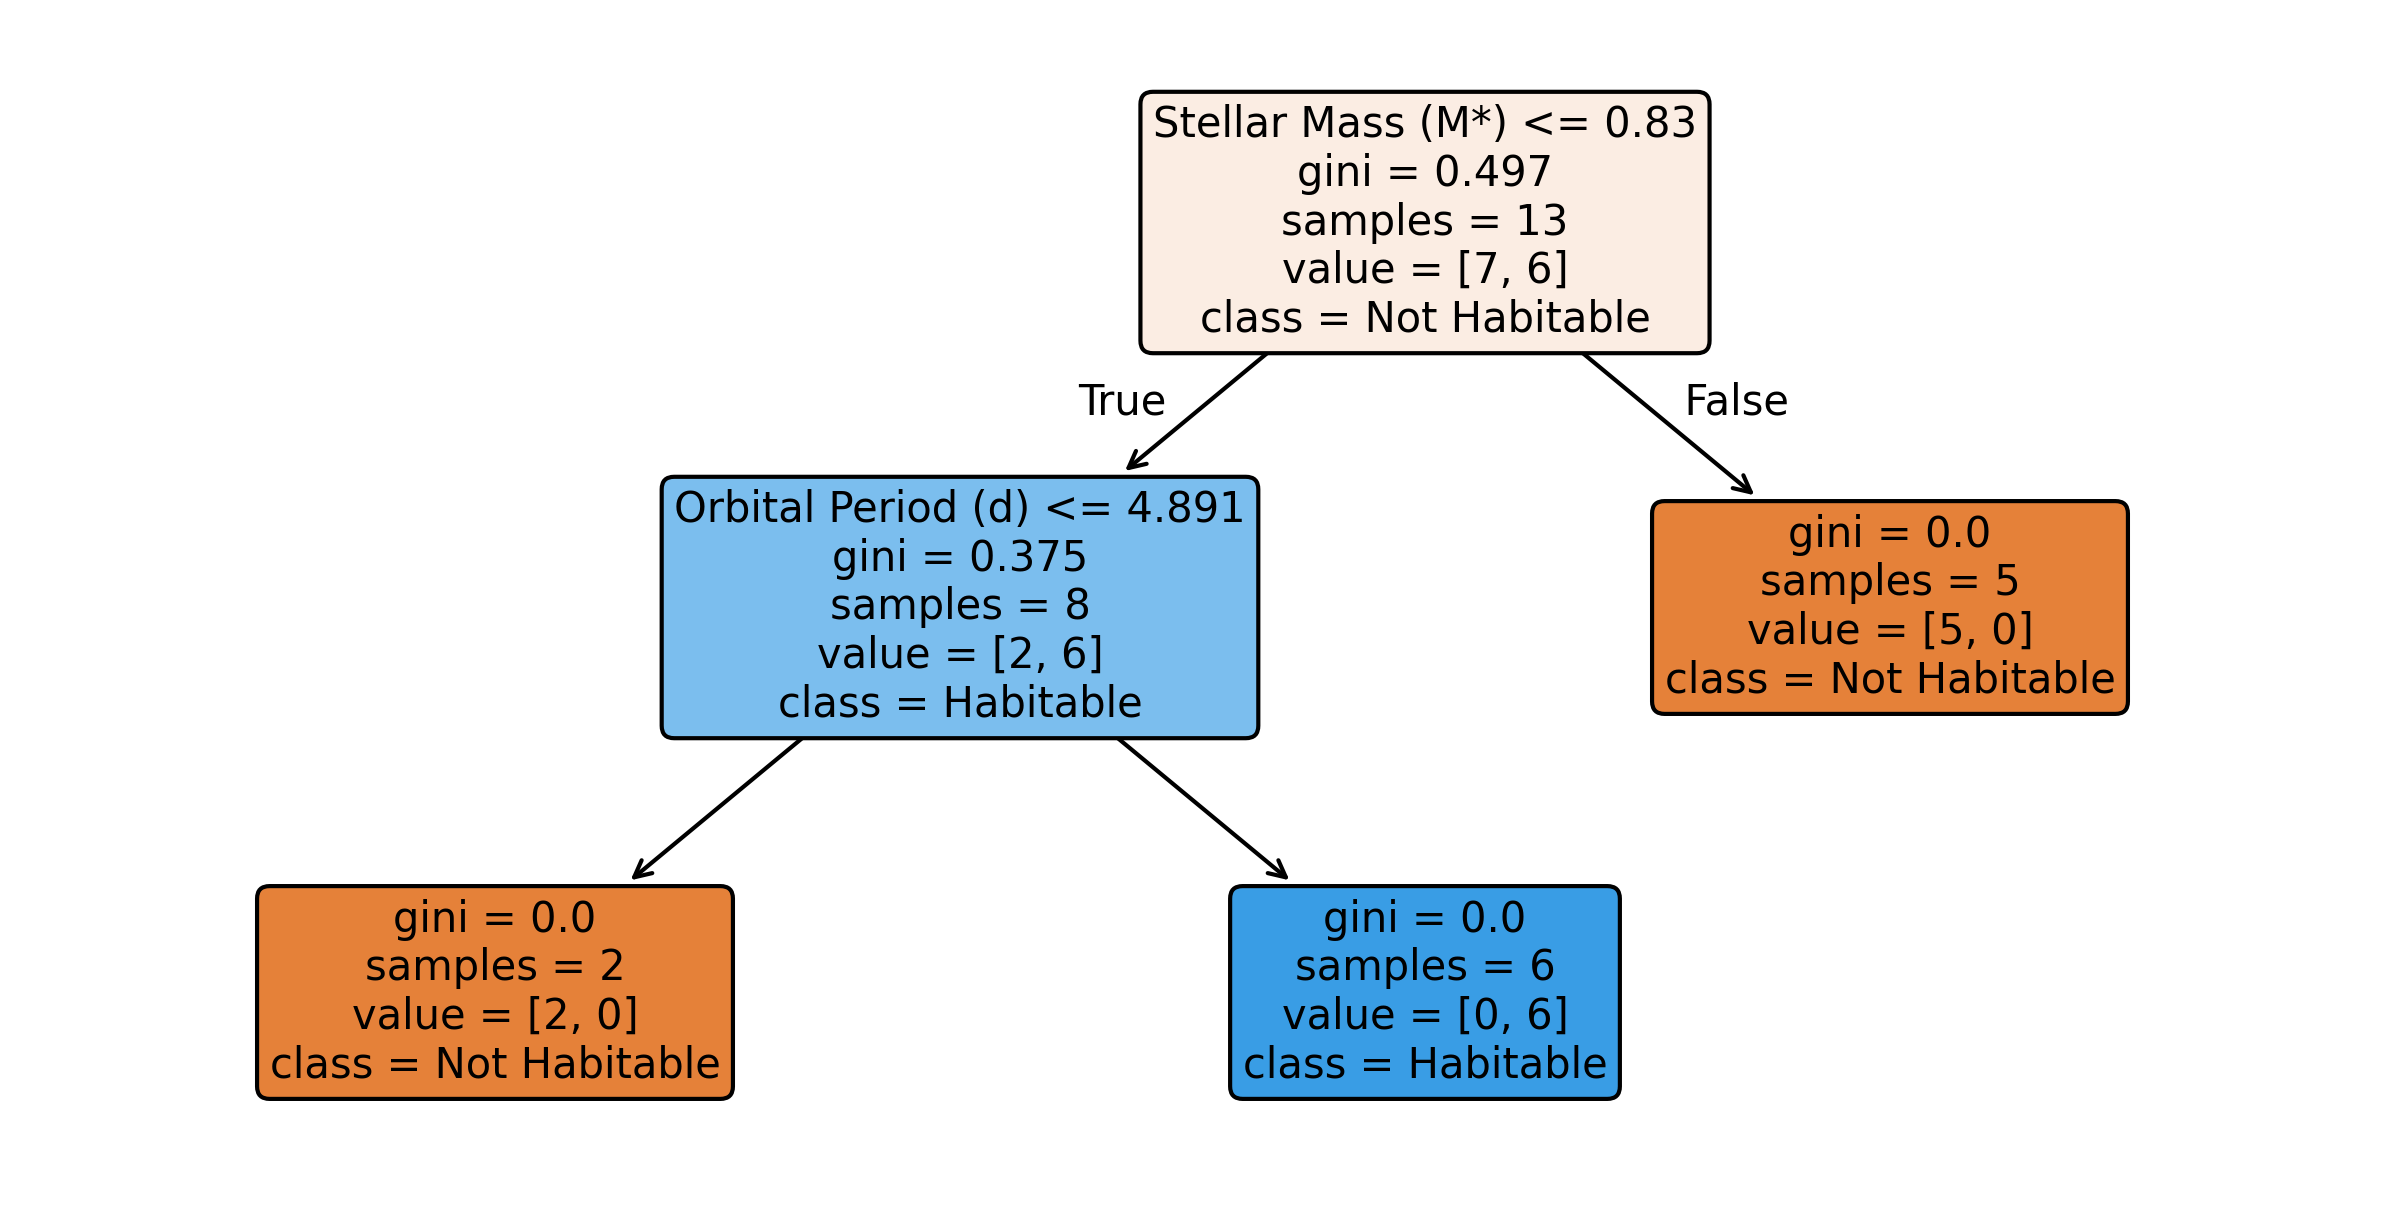

In [22]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

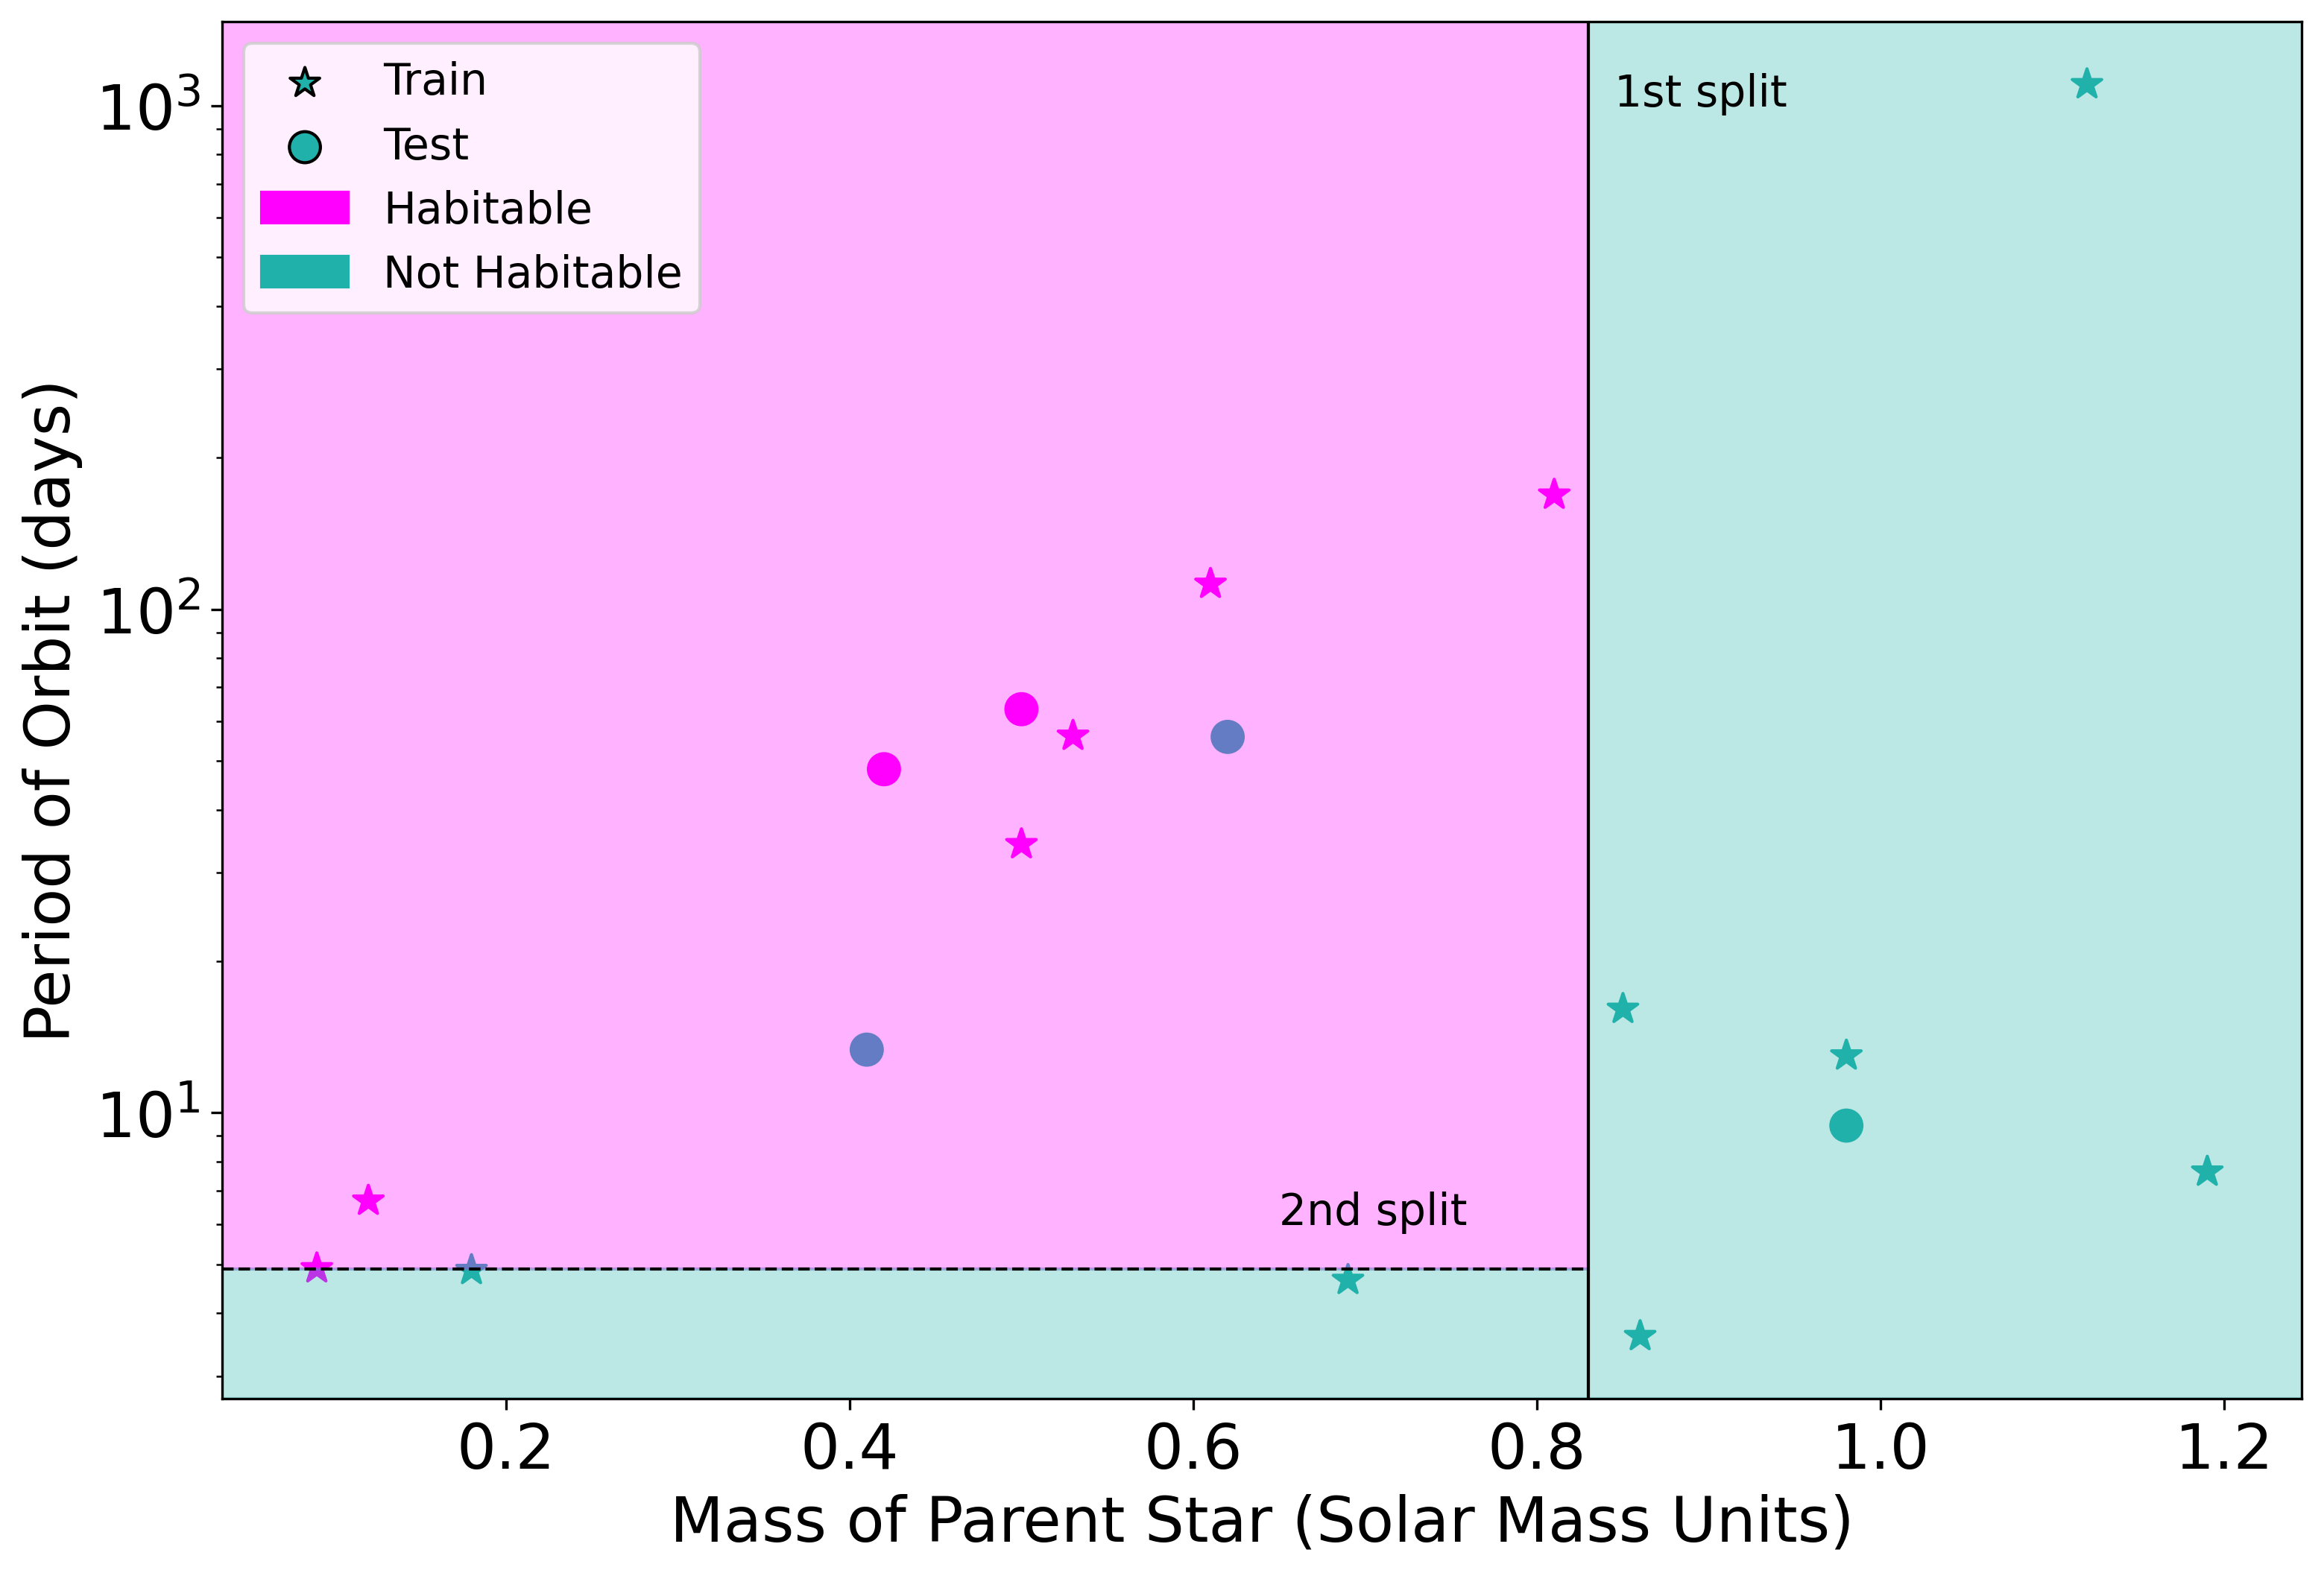

In [23]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)
         
plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1], 
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);


### Pregunta 
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?


- A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

- El porcentaje de clasificaciones correctas (accuracy) es:

 En el set de entrenamiento: 1.0 (o 100%);
 
 En el set de prueba: 0.6 (o 60%)


### usando la métricas de sklearn, podemos encontrar el accuracy


In [24]:
import sklearn.metrics as metrics


In [25]:
ypred = model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [26]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [27]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [28]:
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score

1.0

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?
2. ¿Qué ocurre en el conjunto de prueba?
3. ¿Qué variable aparece en la raíz del árbol?
4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?


1. Sí, el árbol presenta un 100% de accuracy en el conjunto de entrenamiento
2. en el conjunto de prueba se equivoca en un 4% esto puede deberse a que el conjunto tiene muchas limitaciones
3. La masa estelar
4. Me parece que es demasiado simple, necesita más reglas para poder eliminar ese 40% de error que obtuvo en el conjunto de prueba. 

### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [29]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:] 

TestSet2 = LearningSet.iloc[:5,:]

### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

In [30]:
print(f"Tamaño del dataset: {LearningSet.shape[0]} filas, {LearningSet.shape[1]} columnas")

Tamaño del dataset: 18 filas, 5 columnas


In [31]:
print("Categorías de P_HABITABLE")
display(LearningSet['P_HABITABLE'].value_counts())

Categorías de P_HABITABLE


P_HABITABLE
0    10
1     8
Name: count, dtype: int64

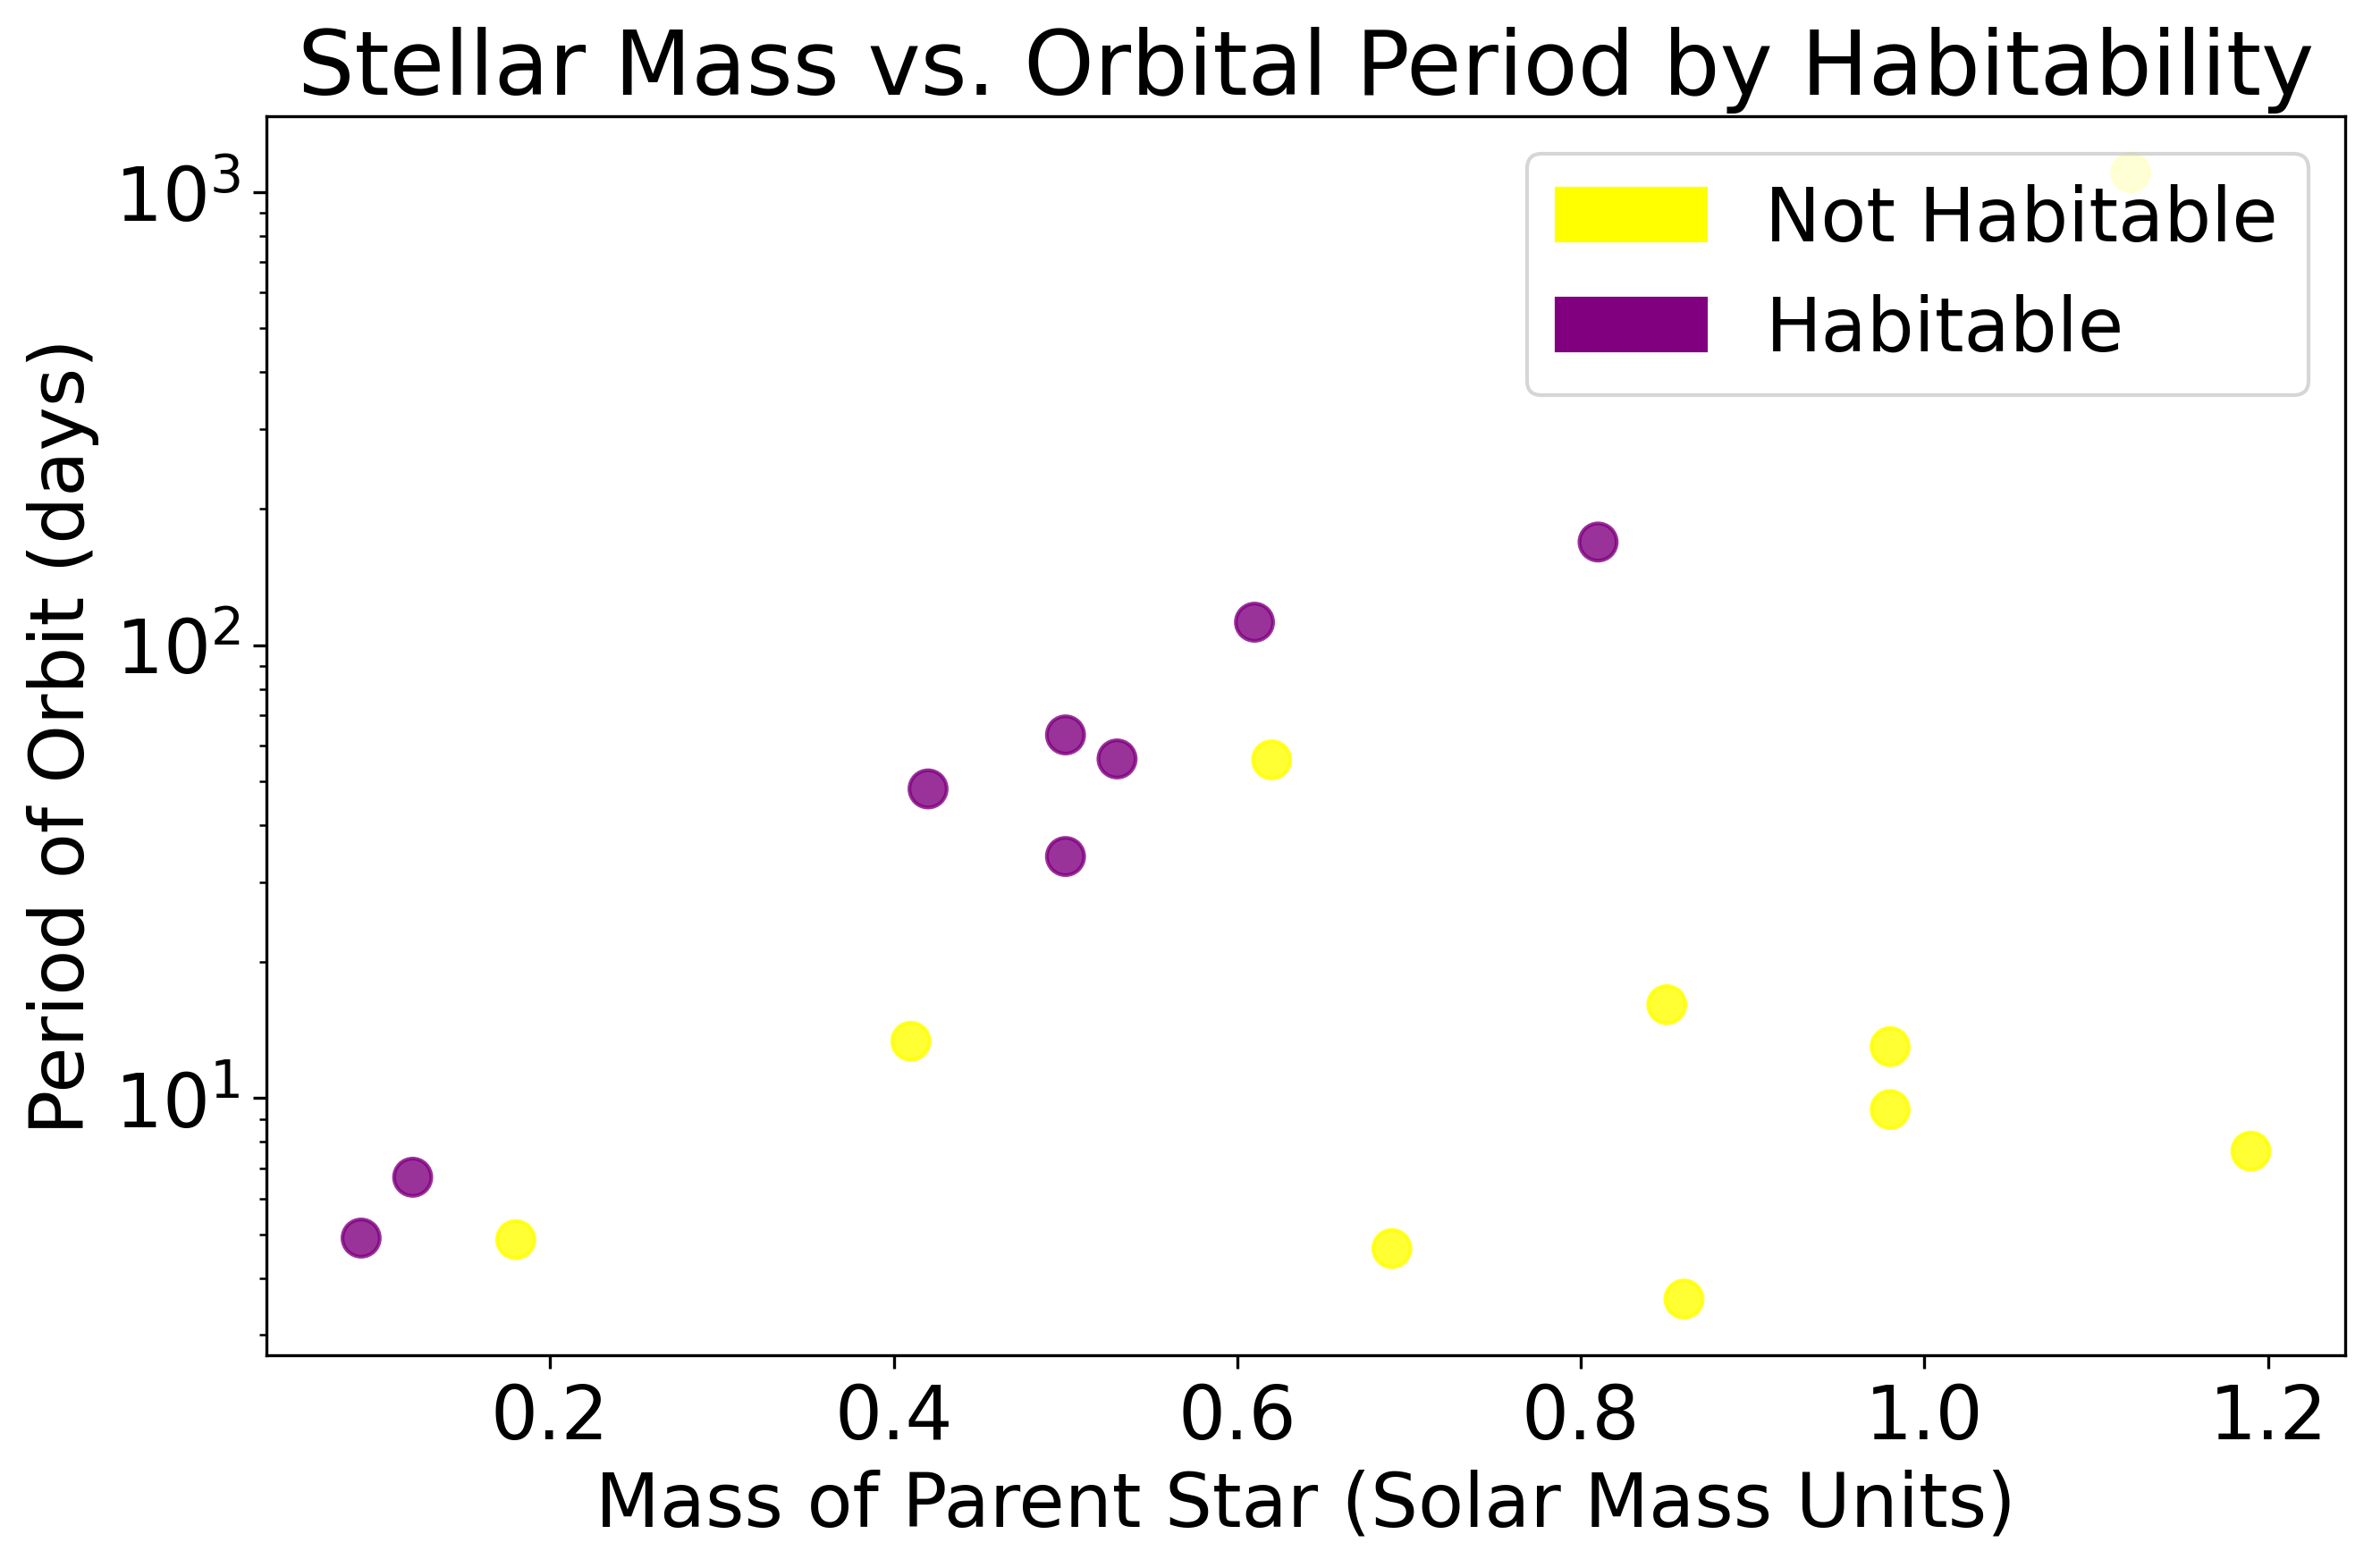

In [32]:
plt.figure(figsize=(10, 6))


cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#FFFF00', '#800080'])

plt.scatter(LearningSet['S_MASS'], LearningSet['P_PERIOD'],
            c=LearningSet['P_HABITABLE'], cmap=cmap, s=100, alpha=0.8)
plt.yscale('log')
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)')
plt.title('Stellar Mass vs. Orbital Period by Habitability')

# Create custom legend handles
yellowpatch = mpatches.Patch(color='#FFFF00', label='Not Habitable')
purplepatch = mpatches.Patch(color='#800080', label='Habitable')
plt.legend(handles=[yellowpatch, purplepatch], loc='upper right')


plt.show()

In [33]:
Xtrain2 = TrainSet2.drop(['P_NAME','P_HABITABLE'],axis=1)
Xtest2 = TestSet2.drop(['P_NAME','P_HABITABLE'],axis=1)
ytrain2 = TrainSet2.P_HABITABLE
ytest2 = TestSet2.P_HABITABLE

In [34]:
model2 = DecisionTreeClassifier(random_state = 3)
model2.fit(Xtrain2, ytrain2)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

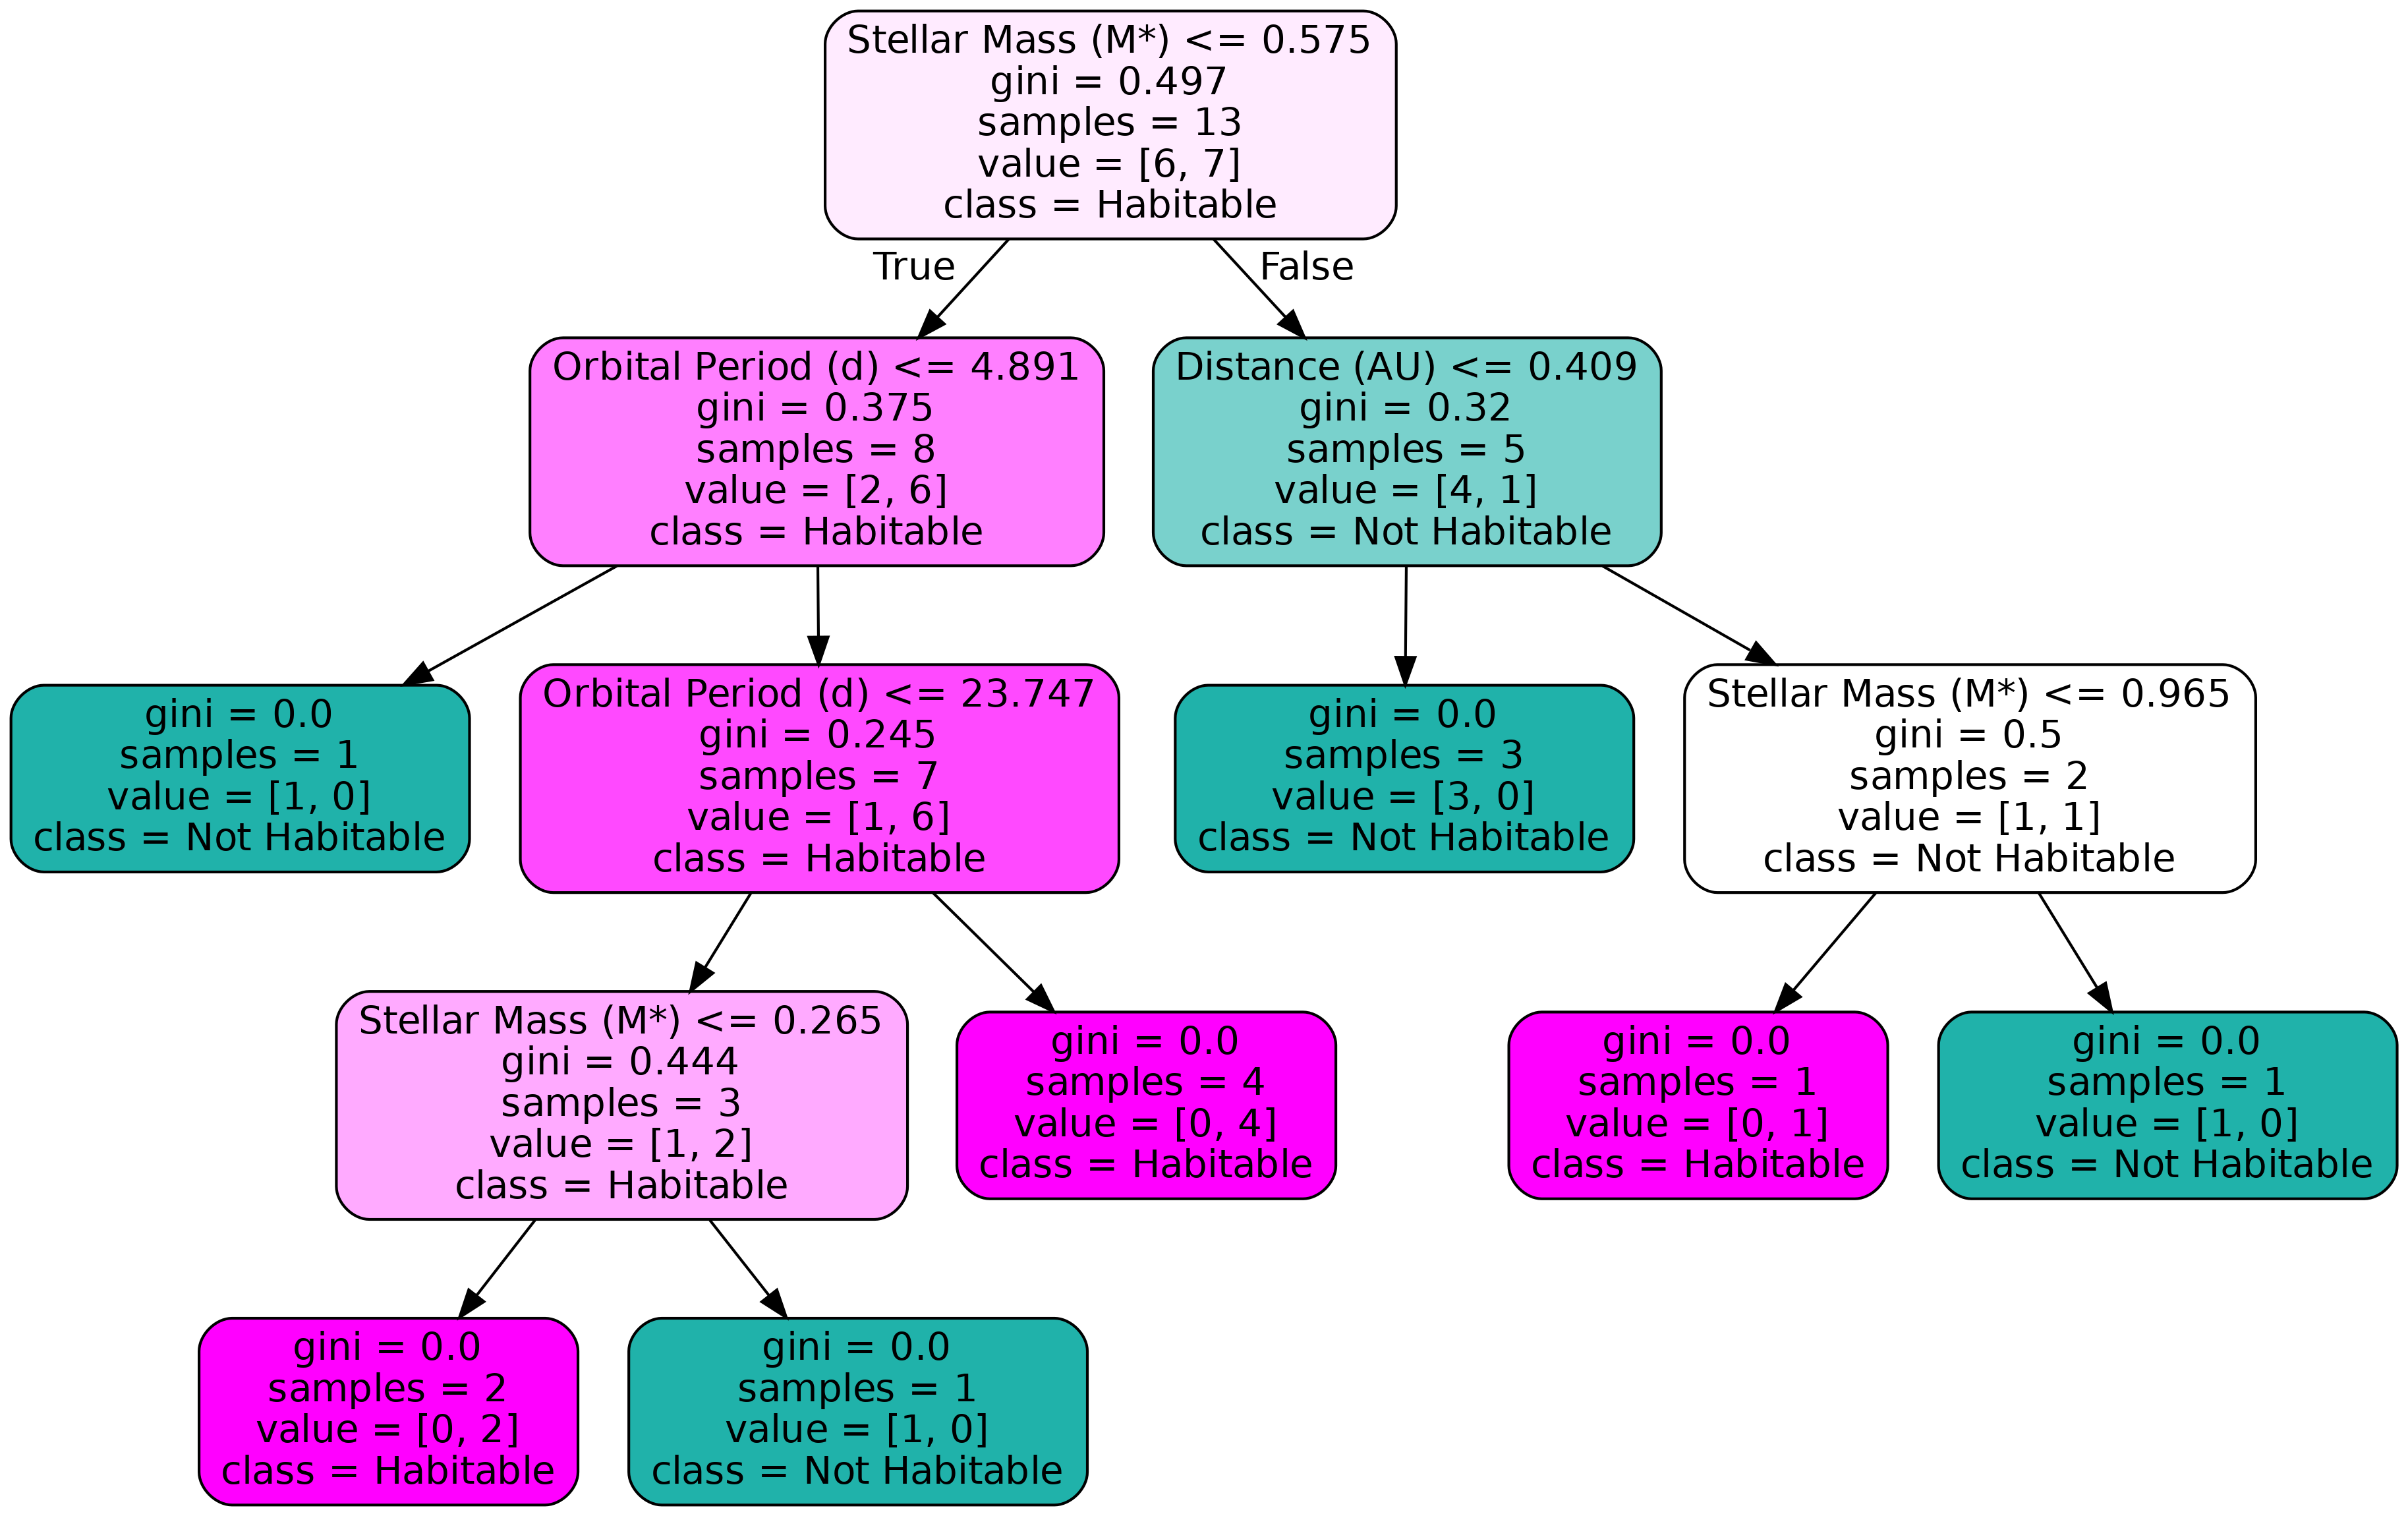

In [35]:
from sklearn.tree import export_graphviz
dot_data = StringIO()
export_graphviz(
            model2,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]

        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

In [62]:
ypred2 = model2.predict(Xtest2)

In [63]:
metrics.accuracy_score(ytest2, ypred2) #test score

1.0

In [64]:
metrics.accuracy_score(ytrain2, model2.predict(Xtrain2)) #train score

1.0

### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento? 

- ¿Y en el conjunto de prueba?

- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?


### Respuesta

- El primer árbol es mucho más sencillo, con una profundidad máxima de 2 y solo 3 nodos hoja. El segundo árbol es notablemente más complejo (más ramificado), alcanzando una profundidad máxima de 4 y terminando en 7 nodos hoja.

- Para ambos árboles, el accuracy en los datos de entrenamiento es del 100%. Podemos saber esto como un hecho porque todos los nodos terminales (las "hojas" donde termina el árbol) en ambas imágenes muestran un índice de impureza gini = 0.0. Esto significa que el algoritmo logró una separación perfecta de las clases para las 13 muestras que se le entregaron en ambos casos.

- En el conjunto de prueba el accuracy también es de 100% para el modelo 2 pero del 60% en el modelo 1. El árbol simple, en este caso, se quedó corto y falló en el 40% de sus predicciones.

- No necesariamente la regla general del Machine Learning nos dice que lo simple generalmente es lo mejor, en este caso funcionó mejor el modelo más compleajo porque habían muy pocos datos, pero ese no es siempre el caso.

### Conclusiones

- Que puede concluir respecto a al ejercicio?

- Cambian los resultados dependiendo del set de datos que utilizamos?

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?

### Respuestas

- Que el rendimiento de un modelo de Machine Learning depende críticamente de las variables que se le entreguen y de su complejidad. Vimos que omitir una variable física crucial (la distancia) provoca subajuste, pero también aprendimos que evaluar modelos con conjuntos de datos minúsculos (13 muestras) hace que los porcentajes de éxito (como ese 100%) sean engañosos o poco robustos a nivel estadístico.

- Sí, absolutamente. Con conjuntos de datos tan pequeños, cualquier cambio mínimo (como qué datos exactos caen en el grupo de entrenamiento y cuáles en el de prueba) altera por completo las reglas matemáticas que construye el árbol. Por eso el segundo árbol cambió su variable principal en la raíz frente al primero.

- No. Ambos árboles clasificarían a la Tierra como "No Habitable".

## k-Nearest Neighbors 

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.




In [37]:
from sklearn import neighbors 
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [38]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [39]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [40]:
model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [41]:
Xtrain.iloc[:,:2] 

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [42]:
model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [43]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [44]:
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [45]:
model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [46]:
for i in range(len(TestSet)): # para cada elemento del set de prueba
    
    print(model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.05672308015779


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles 

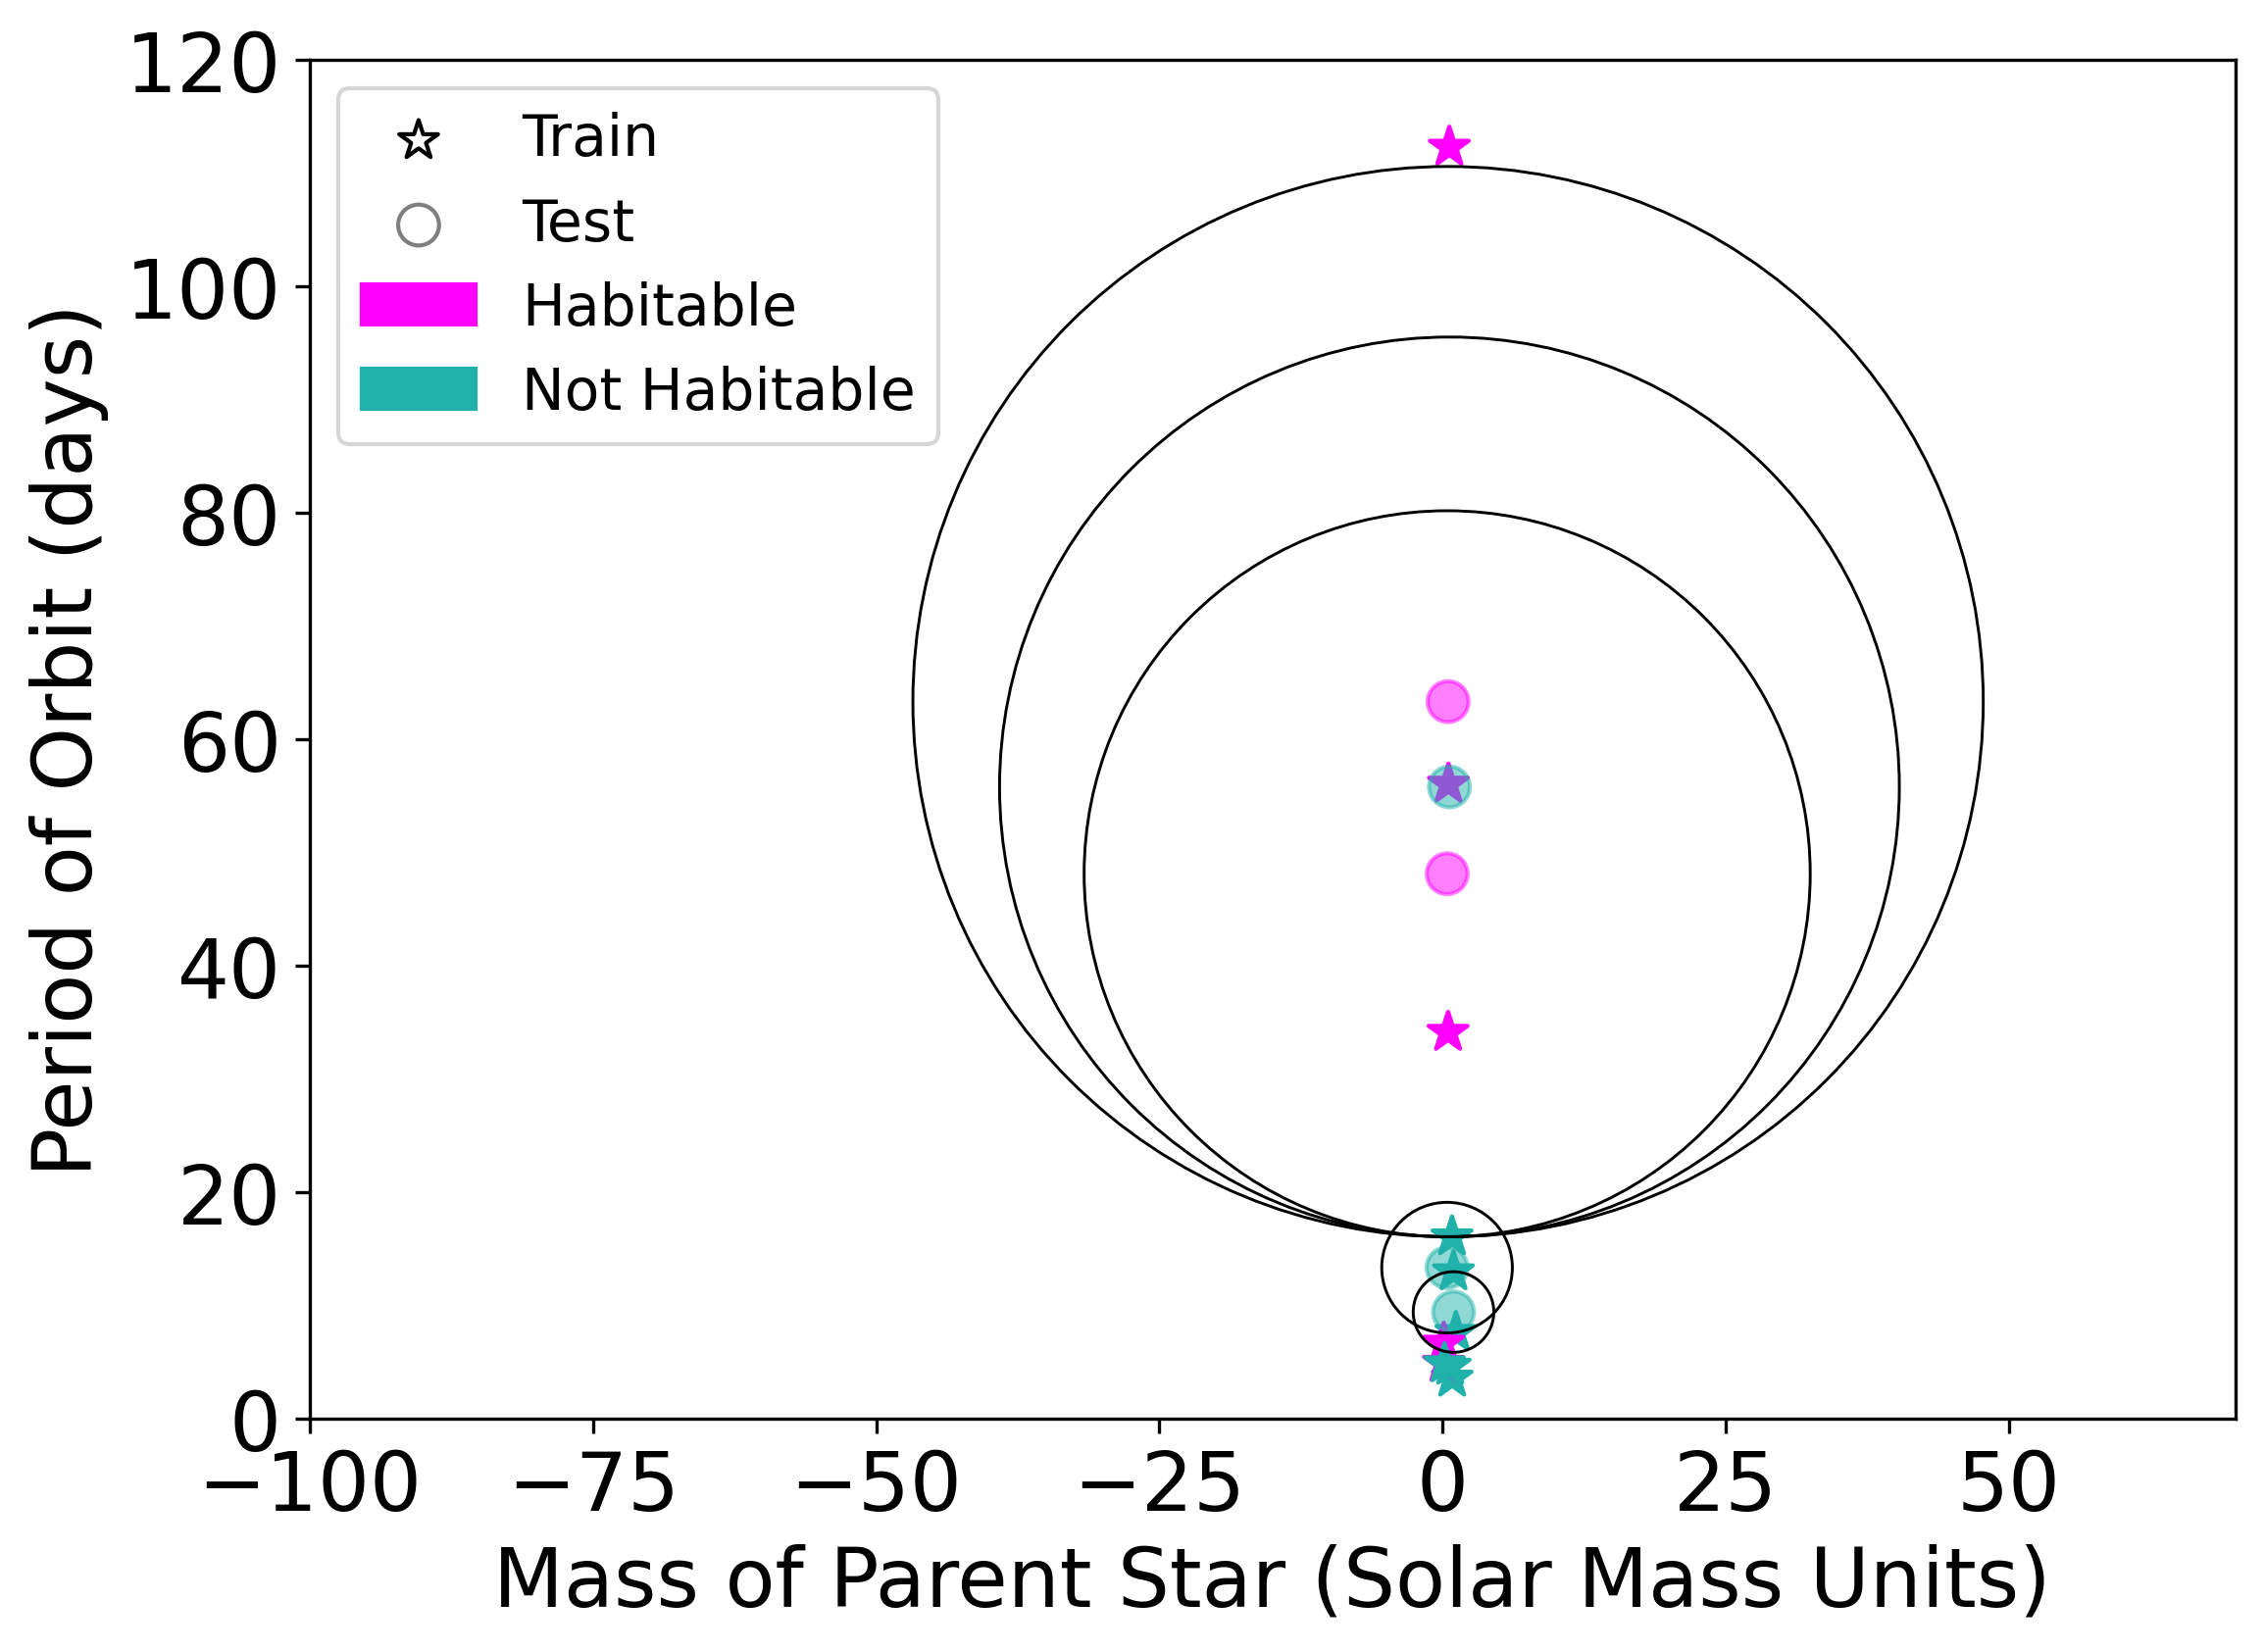

In [68]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap) 

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5) 

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)
    
plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-100,70)
plt.ylim(0,120)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico?

R: 
Como kNN calcula la distancia euclidiana entre los puntos, el eje Y está dominando por completo el modelo. El algoritmo está decidiendo quién es "vecino" casi exclusivamente basándose en el período orbital, ignorando la masa.

 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [48]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [49]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [50]:
scaledXTrain = scaler.transform(Xtrain)

In [51]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [52]:
scaledXtest = scaler.transform(Xtest) # 

In [53]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

Accuracy en el set de entrenamiento (kNN, 2 features, escalado): 0.8461538461538461
Accuracy en el set de prueba (kNN, 2 features, escalado): 0.8


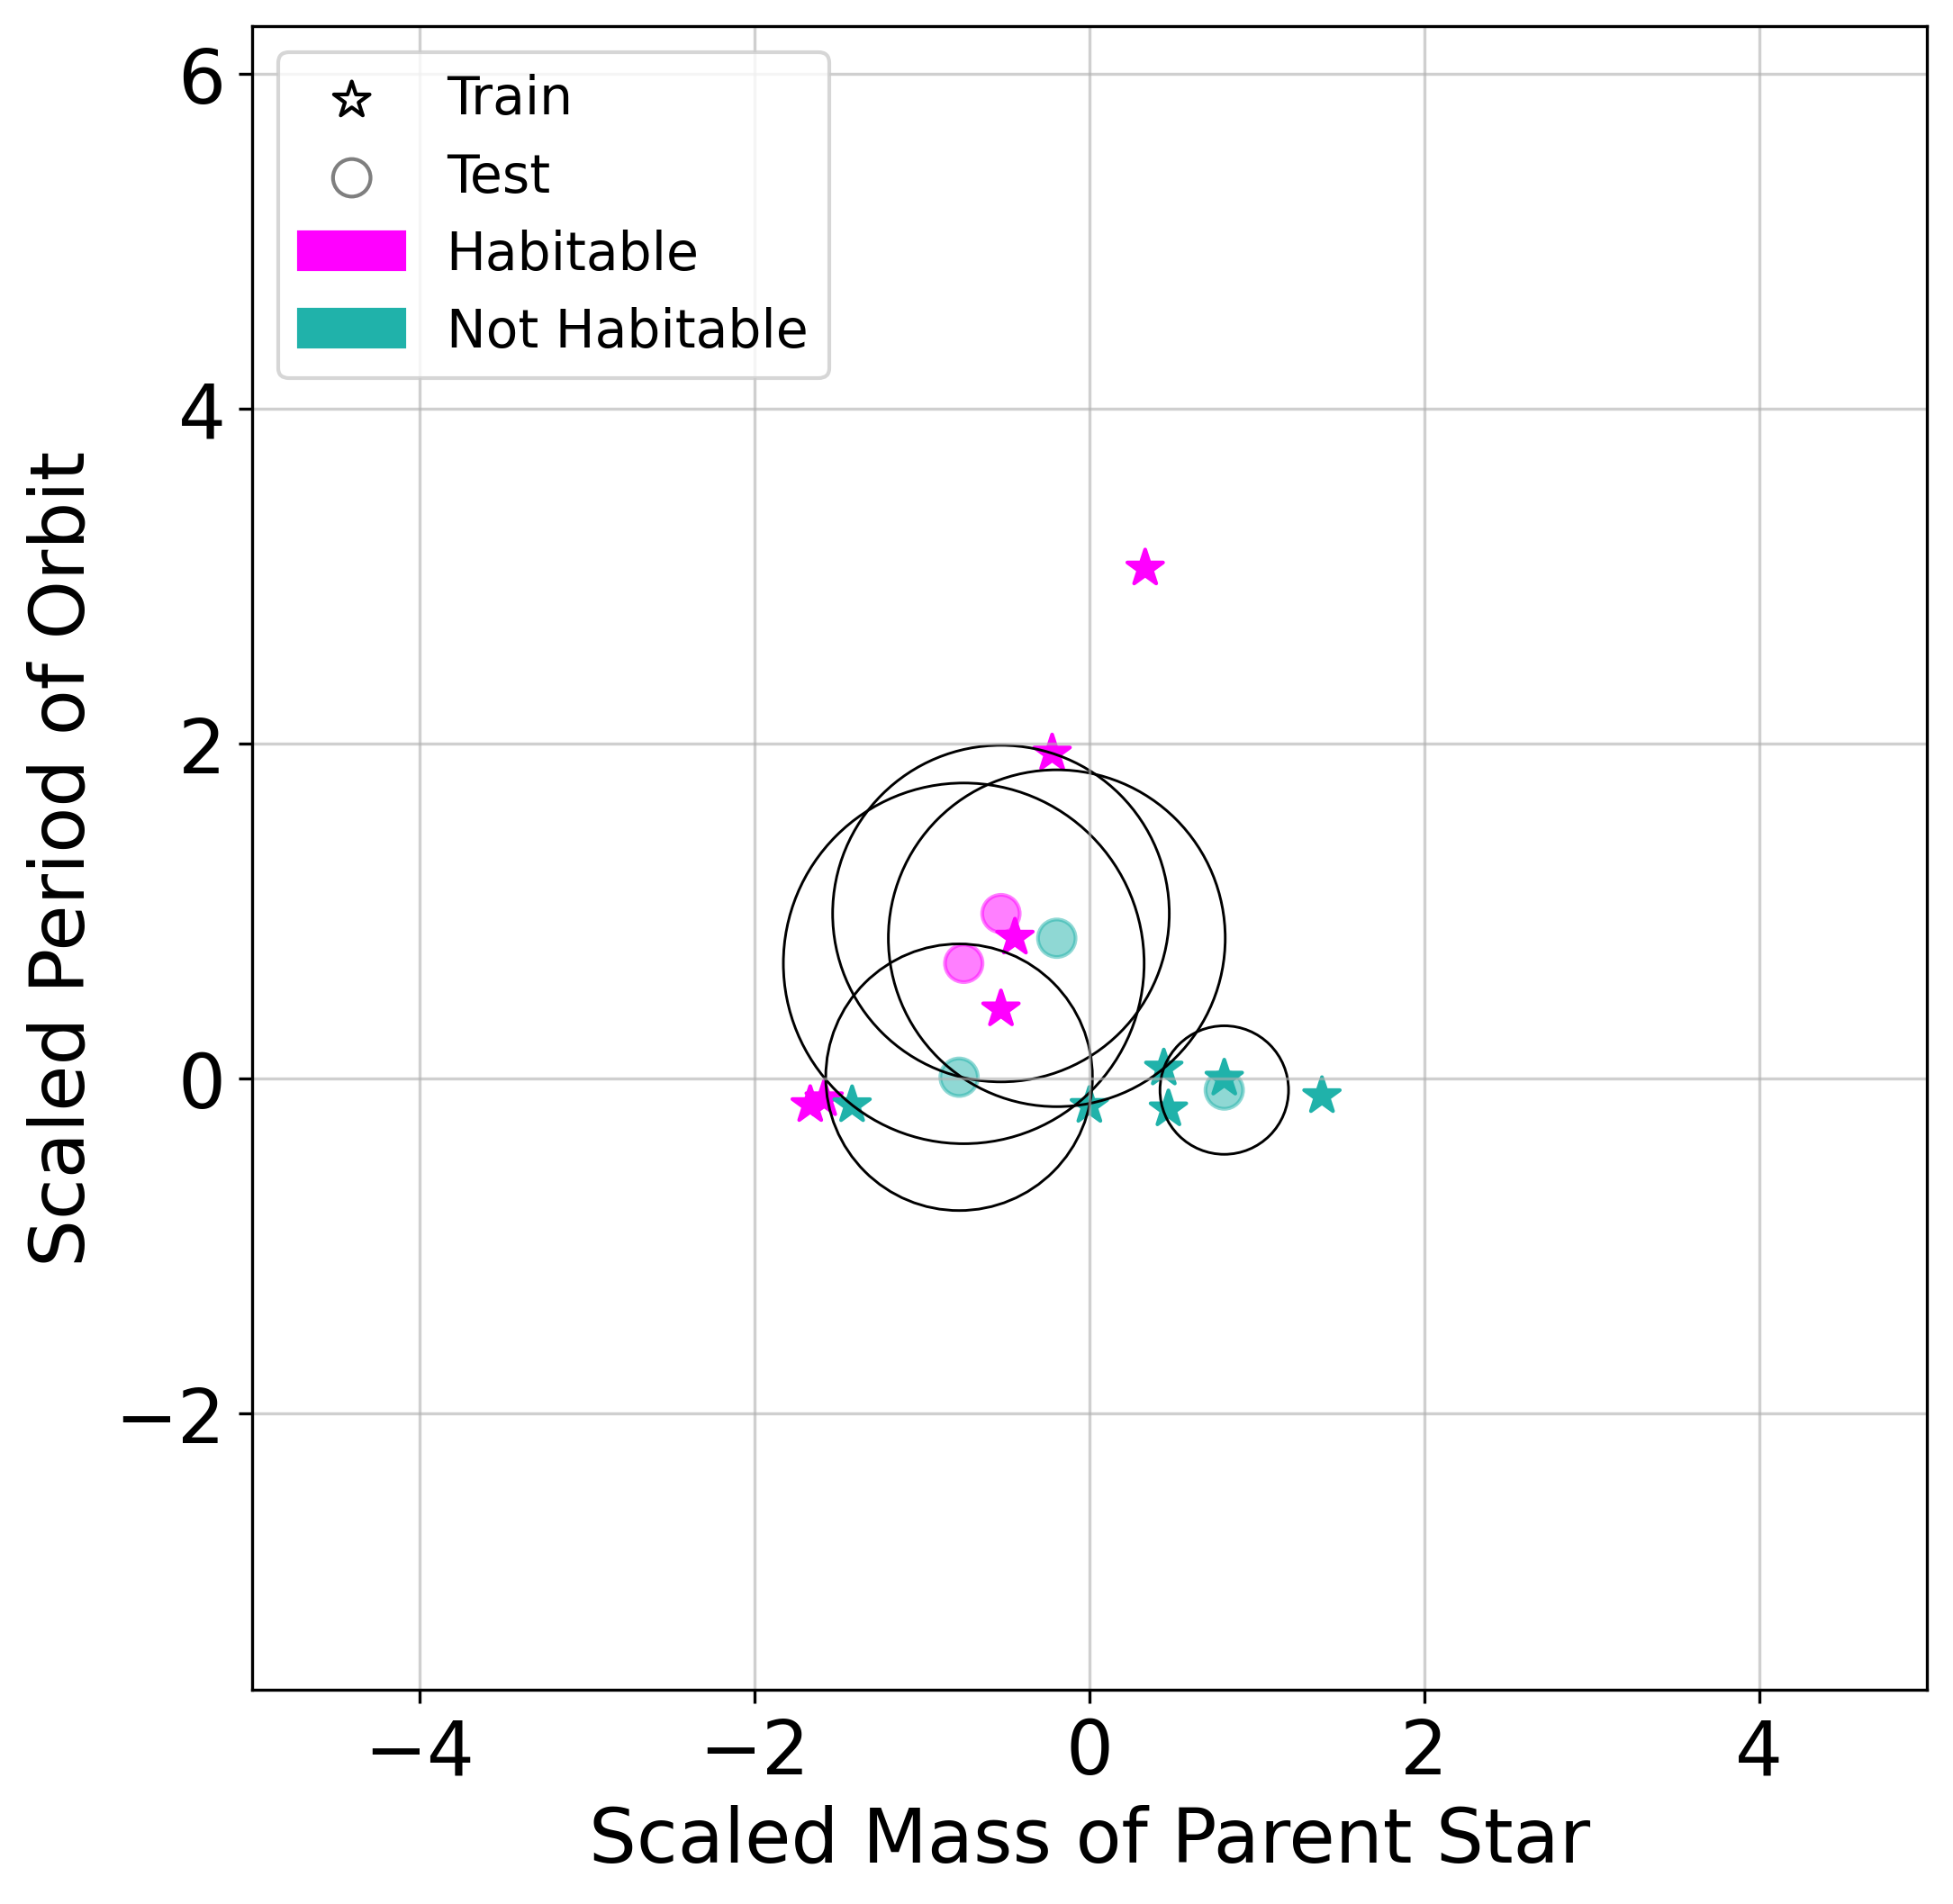

In [54]:

model_scaled_2d = neighbors.KNeighborsClassifier(n_neighbors = 3)

model_scaled_2d.fit(scaledXTrain[:, :2], ytrain)


ypred_scaled_train_2d = model_scaled_2d.predict(scaledXTrain[:, :2])
ypred_scaled_test_2d = model_scaled_2d.predict(scaledXtest[:, :2])

# Calculate and print accuracy for the 2-feature scaled model
print(f"Accuracy en el set de entrenamiento (kNN, 2 features, escalado): {metrics.accuracy_score(ytrain, ypred_scaled_train_2d)}")
print(f"Accuracy en el set de prueba (kNN, 2 features, escalado): {metrics.accuracy_score(ytest, ypred_scaled_test_2d)}")

# --- Visualization part ---
plt.figure(figsize=(8,8)) # Changed to a square figure size
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

# Scatter plot for scaled training data (first two features)
plt.scatter(scaledXTrain[:, 0], scaledXTrain[:, 1], marker = '*',facecolor = 'None',
            c = ytrain, s = 100, label = 'Train', cmap=cmap)

# Scatter plot for scaled test data (first two features)
plt.scatter(scaledXtest[:, 0], scaledXtest[:, 1], marker = 'o',facecolor = 'None',
            c = ytest, s = 100, label = 'Test', cmap=cmap, alpha=0.5)

# Plot neighbors circles for each test point
max_radius_overall = 0
for i in range(len(scaledXtest)): # for each element in the scaled test set
    # Get the distances to k neighbors for the current test point
    # Pass a slice to keep dimensions (expected by kneighbors is (n_samples, n_features))
    distances, _ = model_scaled_2d.kneighbors(scaledXtest[i:i+1, :2])
    radius = distances[0, 2] # Use the distance to the 3rd neighbor as radius
    if radius > max_radius_overall: # Keep track of the largest radius
        max_radius_overall = radius

    circle1=plt.Circle((scaledXtest[i, 0], scaledXtest[i, 1]), radius,
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)

plt.axis('equal') # Set aspect ratio to equal for correct circle appearance

# Determine limits dynamically from scaled data and max_radius_overall for better fit
all_scaled_x = np.concatenate((scaledXTrain[:, 0], scaledXtest[:, 0]))
all_scaled_y = np.concatenate((scaledXTrain[:, 1], scaledXtest[:, 1]))

# Expand limits to include max_radius around all points, plus a small buffer
x_min = all_scaled_x.min() - max_radius_overall * 1.1
x_max = all_scaled_x.max() + max_radius_overall * 1.1
y_min = all_scaled_y.min() - max_radius_overall * 1.1
y_max = all_scaled_y.max() + max_radius_overall * 1.1

plt.xlim(-5, 5) # Set x-axis limits as requested
plt.ylim(y_min, 4) # Set y-axis limits based on data and max radius

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

# Create proxy artists for the scattered points so they appear correctly in the legend
# (since facecolor='None' makes them invisible in legend default)
proxy_train = plt.scatter([], [], marker='*', s=100, facecolor='None', edgecolor='k', label='Train')
proxy_test = plt.scatter([], [], marker='o', s=100, facecolor='None', edgecolor='k', label='Test', alpha=0.5)

plt.legend(handles=[proxy_train, proxy_test, magentapatch, bluepatch],
           loc = 'upper left', fontsize = 14)

plt.xlabel('Scaled Mass of Parent Star')
plt.ylabel('Scaled Period of Orbit');

plt.grid(True, which="both", ls="-", alpha=0.6)
plt.show()

**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [69]:
# Initialize kNN model using all features
model_scaled_all_features = neighbors.KNeighborsClassifier(n_neighbors = 3)

# Fit the model using all scaled features from the training set
model_scaled_all_features.fit(scaledXTrain, ytrain)

# Generate predictions for the full-feature scaled data
ypred_scaled_train_all_features = model_scaled_all_features.predict(scaledXTrain)
ypred_scaled_test_all_features = model_scaled_all_features.predict(scaledXtest)

# Calculate and print accuracy for the full-feature scaled model
print(f"Accuracy en el set de entrenamiento (kNN, todas las features, escalado): {metrics.accuracy_score(ytrain, ypred_scaled_train_all_features)}")
print(f"Accuracy en el set de prueba (kNN, todas las features, escalado): {metrics.accuracy_score(ytest, ypred_scaled_test_all_features)}")

Accuracy en el set de entrenamiento (kNN, todas las features, escalado): 0.8461538461538461
Accuracy en el set de prueba (kNN, todas las features, escalado): 0.8


### Preguntas 

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?

- Compare las fortalezas y debilidades de DT y kNN

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?


### Respuestas


- No. Los árboles de decisión (DT) no necesitan escalado. Funcionan haciendo cortes secuenciales, por lo que solo les importa el orden de los valores, no su magnitud absoluta.

- DT: 
    Fortalezas: Muy fáciles de interpretar (reglas claras), no requieren escalado de datos, manejan bien variables irrelevantes.

    Debilidades: Altamente propensos al sobreajuste (memorizan) y muy inestables (pequeños cambios en los datos generan árboles totalmente distintos).

- kNN:

    Fortalezas: Muy intuitivo, se adapta naturalmente a patrones no lineales o formas complejas en los datos.

    Debilidades: Sensible a la escala (requiere normalización), no te da reglas claras de por qué tomó una decisión (menos interpretable), y es lento si el dataset es gigante.

- El enfoque es totalmente distinto. Un DT divide el espacio en cajas rectangulares haciendo preguntas de "sí o no" una variable a la vez. En cambio, kNN clasifica por geometría y proximidad espacial

- Porque mide qué tan bien el modelo "memorizó" los datos que ya vio, no qué tan bien "aprendió" a resolver el problema.

- kNN calcula distancias matemáticas. Si el Periodo Orbital va de 0 a 140 y la Masa de 0 a 1, el Periodo dominará el cálculo de la distancia y el modelo ignorará la Masa. El árbol de decisión no mide distancias; simplemente ordena los números de menor a mayor y busca un punto de corte, por lo que la escala no le afecta.

- Elegiría kNN (previamente escalado). Con datasets tan pequeños, los árboles de decisión son demasiado caóticos e inestables, tendiendo rápidamente al sobreajuste o ignorando variables vitales. kNN, con un k=3, demostró ser más equilibrado para este problema, capturando la relación conjunta entre masa, periodo y distancia con un rendimiento consistente en la prueba (80%).

## Desafío

- Estudiar el efecto del valor de k Elegir distintos valores de k y graficar k vs accuracy

- Explorar efecto de hyperparametros de un arbol - elegir 2 hyperparametros, cambiar los valores y comparar con modelo inicial 

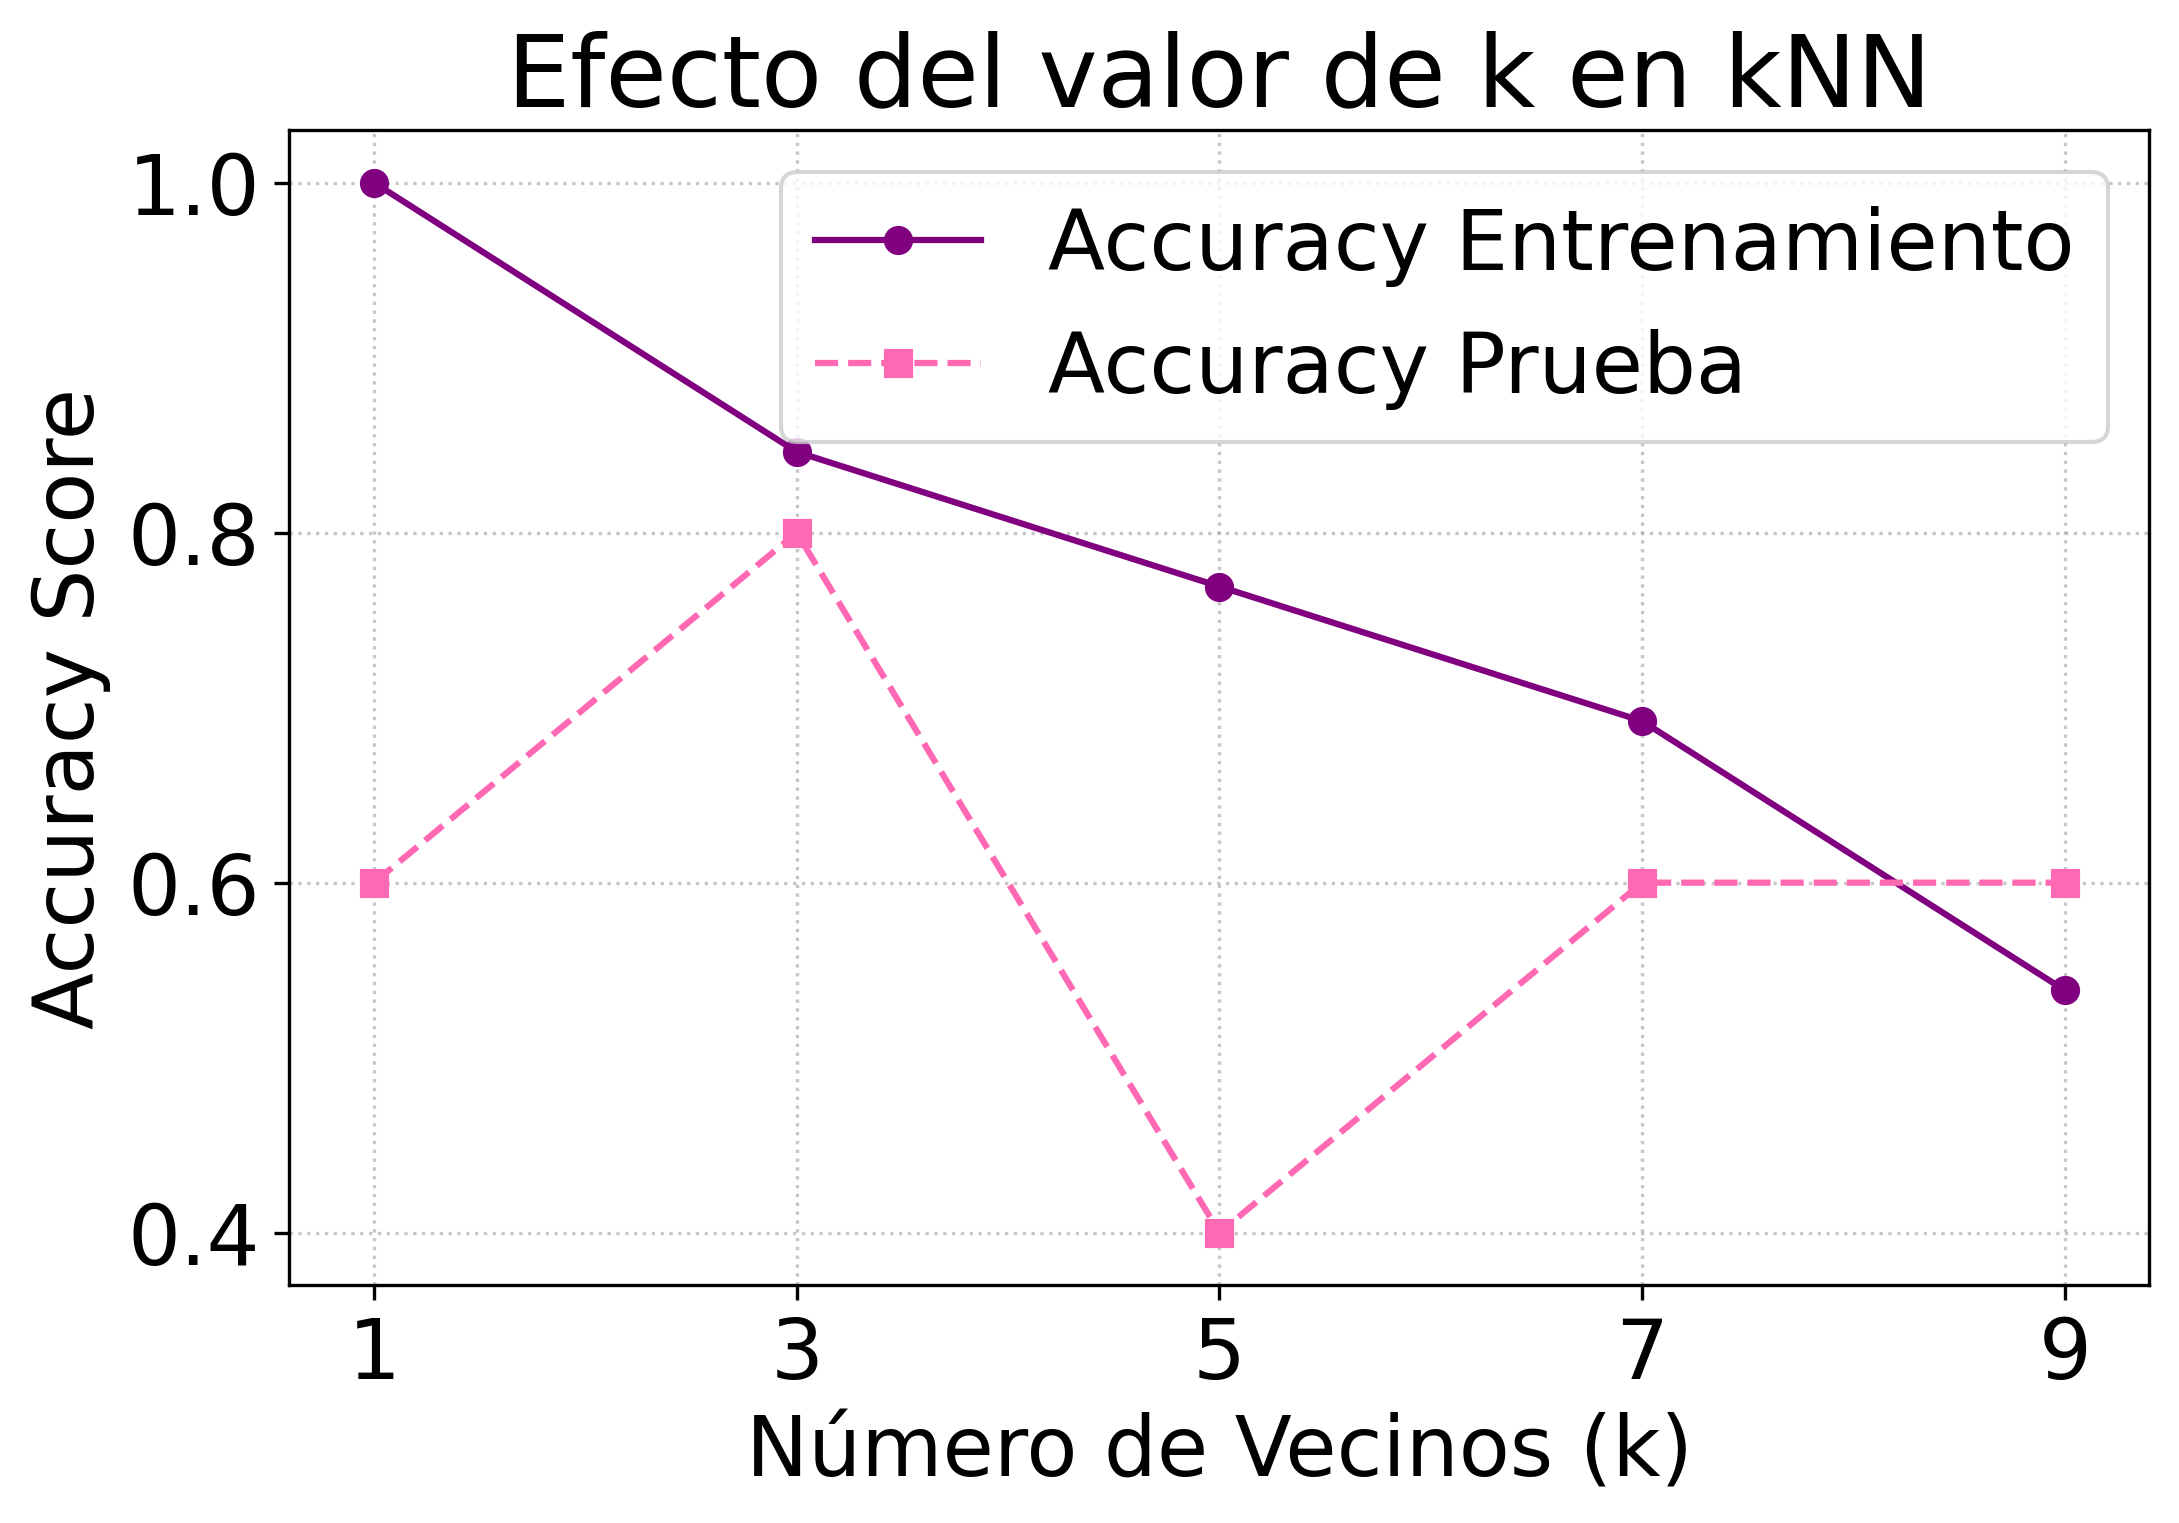

In [73]:

# Listas para guardar los resultados
k_values = [1, 3, 5, 7, 9] # Usamos impares pequeños por el tamaño del dataset
train_accuracies = []
test_accuracies = []

# Probar cada valor de k
for k in k_values:
    # 1. Inicializar el modelo con el k actual
    knn = neighbors.KNeighborsClassifier(n_neighbors=k)
    
    # 2. Entrenar usando TODAS las características escaladas
    knn.fit(scaledXTrain, ytrain)
    
    # 3. Predecir
    y_pred_train = knn.predict(scaledXTrain)
    y_pred_test = knn.predict(scaledXtest)
    
    # 4. Calcular y guardar accuracy
    train_accuracies.append(metrics.accuracy_score(ytrain, y_pred_train))
    test_accuracies.append(metrics.accuracy_score(ytest, y_pred_test))

# --- Graficar los resultados ---
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker='o', linestyle='-', color='purple', label='Accuracy Entrenamiento')
plt.plot(k_values, test_accuracies, marker='s', linestyle='--', color='hotpink', label='Accuracy Prueba')

plt.title('Efecto del valor de k en kNN')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Accuracy Score')
plt.xticks(k_values) # Forzar que el eje X muestre solo los k que probamos
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Notamos que el accuracy baja a medida que aumentan los k, para los datos de entrenamiento el accuracy es 100% cuando k = 1. En cambio el accuracy más alto para los datos de prueba es con k = 3.

In [74]:
from sklearn import tree

# 1. Recordatorio del Modelo Inicial (por defecto)
dt_initial = tree.DecisionTreeClassifier(random_state=42)
dt_initial.fit(Xtrain, ytrain)
acc_test_initial = metrics.accuracy_score(ytest, dt_initial.predict(Xtest))

# 2. Modelo Modificado 1: Limitando la profundidad (max_depth=2)
# Esto obliga al árbol a ser más simple (como el primero que me mostraste)
dt_mod_1 = tree.DecisionTreeClassifier(max_depth=2, random_state=42)
dt_mod_1.fit(Xtrain, ytrain)
acc_test_mod_1 = metrics.accuracy_score(ytest, dt_mod_1.predict(Xtest))

# 3. Modelo Modificado 2: Exigiendo más muestras por hoja (min_samples_leaf=3)
# Esto evita que cree hojas exclusivas para 1 solo dato (evita sobreajuste)
dt_mod_2 = tree.DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
dt_mod_2.fit(Xtrain, ytrain)
acc_test_mod_2 = metrics.accuracy_score(ytest, dt_mod_2.predict(Xtest))

# 4. Modelo Combinado: Modificando ambos parámetros a la vez
dt_mod_3 = tree.DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, random_state=42)
dt_mod_3.fit(Xtrain, ytrain)
acc_test_mod_3 = metrics.accuracy_score(ytest, dt_mod_3.predict(Xtest))

# --- Imprimir la comparación ---
print("Comparación de Hiperparámetros en Decision Tree")
print(f"Modelo Inicial (Por defecto)    -> Accuracy Prueba: {acc_test_initial:.2f}")
print(f"Modelo Modificado (max_depth=2) -> Accuracy Prueba: {acc_test_mod_1:.2f}")
print(f"Modelo Modificado (min_leaf=3)  -> Accuracy Prueba: {acc_test_mod_2:.2f}")
print(f"Modelo Combinado (depth=3, leaf=2)-> Accuracy Prueba: {acc_test_mod_3:.2f}")

Comparación de Hiperparámetros en Decision Tree
Modelo Inicial (Por defecto)    -> Accuracy Prueba: 0.60
Modelo Modificado (max_depth=2) -> Accuracy Prueba: 0.60
Modelo Modificado (min_leaf=3)  -> Accuracy Prueba: 0.60
Modelo Combinado (depth=3, leaf=2)-> Accuracy Prueba: 0.60


Si los datos no tienen un patrón que el algoritmo pueda capturar de cierta forma, o si hay muy pocas muestras para notar la diferencia, los resultados se van a estancar exactamente de esta manera.